## 1. Dataset Loading

The analysis uses the **UCI Online Retail dataset**, which contains 541,909 transaction records from a UK-based online retailer.

### Dataset characteristics

- **Rows:** 541,909
- **Columns:** 8
- **Period:** December 2010 – December 2011
- **Countries:** 38
- **Original variables:** InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, Country
- **Cancellations:** Identified by invoice numbers beginning with `C`
- **Missing CustomerID:** Customer-level analysis is limited to records with known CustomerID

The dataset is transaction-level data, so each row represents a product line within an invoice rather than a complete customer order.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

df = pd.read_excel("data/Online Retail.xlsx")

print("Dataset loaded successfully!")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully!
Rows: 541,909
Columns: 8


In [11]:
print("Column names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nData types:")
display(df.dtypes)

print("\nDataset information:")
df.info()

Column names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

First 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom



Data types:


InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object


Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [12]:
missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_summary = missing_summary.sort_values(
    by="Missing Values",
    ascending=False
)

display(missing_summary)

,Missing Values,Missing Percentage
CustomerID,135080,24.93
Description,1454,0.27
StockCode,0,0.00
InvoiceNo,0,0.00
Quantity,0,0.00
InvoiceDate,0,0.00
UnitPrice,0,0.00
Country,0,0.00


In [13]:
missing_customer = df[df["CustomerID"].isna()]

print(f"Transactions with missing CustomerID: {len(missing_customer):,}")

print("\nTotal quantity:")
print(f"{missing_customer['Quantity'].sum():,}")

print("\nTotal transaction value:")
print(
    f"£{(missing_customer['Quantity'] * missing_customer['UnitPrice']).sum():,.2f}"
)

print("\nCountries represented:")
display(
    missing_customer["Country"]
    .value_counts()
    .head(10)
)

print("\nSample transactions:")
display(missing_customer.head(10))

Transactions with missing CustomerID: 135,080

Total quantity:
269,562

Total transaction value:
£1,447,682.12

Countries represented:


Country
United Kingdom    133600
EIRE                 711
Hong Kong            288
Unspecified          202
Switzerland          125
France                66
Israel                47
Portugal              39
Bahrain                2
Name: count, dtype: int64


Sample transactions:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom
1447,536544,21790,VINTAGE SNAP CARDS,9,2010-12-01 14:32:00,1.66,NaN,United Kingdom
1448,536544,21791,VINTAGE HEADS AND TAILS CARD GAME,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1449,536544,21801,CHRISTMAS TREE DECORATION WITH BELL,10,2010-12-01 14:32:00,0.43,NaN,United Kingdom
1450,536544,21802,CHRISTMAS TREE HEART DECORATION,9,2010-12-01 14:32:00,0.43,NaN,United Kingdom
1451,536544,21803,CHRISTMAS TREE STAR DECORATION,11,2010-12-01 14:32:00,0.43,NaN,United Kingdom


In [14]:
# Verify overall dataset statistics

print("===== OVERALL DATASET CHECK =====")

print(f"Total rows: {len(df):,}")
print(f"Total columns: {df.shape[1]}")

print(f"\nTotal quantity: {df['Quantity'].sum():,}")

print(f"Total transaction value: £{(df['Quantity'] * df['UnitPrice']).sum():,.2f}")

print("\nCountries represented in the FULL dataset:")
print(df["Country"].value_counts())

print("\nUnique countries:")
print(df["Country"].nunique())

print("\nMissing CustomerID:")
print(df["CustomerID"].isna().sum())

print("\nMissing Description:")
print(df["Description"].isna().sum())

===== OVERALL DATASET CHECK =====
Total rows: 541,909
Total columns: 8

Total quantity: 5,176,450
Total transaction value: £9,747,747.93

Countries represented in the FULL dataset:
Country
United Kingdom          495478
Germany                   9495
France                    8557
EIRE                      8196
Spain                     2533
Netherlands               2371
Belgium                   2069
Switzerland               2002
Portugal                  1519
Australia                 1259
Norway                    1086
Italy                      803
Channel Islands            758
Finland                    695
Cyprus                     622
Sweden                     462
Unspecified                446
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
Israel                     297
USA                        291
Hong Kong                  288
Singapore                  229
Iceland                    182
Canad

In [15]:
duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count:,}")
print(f"Duplicate percentage: {duplicate_count / len(df) * 100:.2f}%")

Duplicate rows: 5,268
Duplicate percentage: 0.97%


In [16]:
duplicates = df[df.duplicated(keep=False)].sort_values(
    by=["InvoiceNo", "StockCode", "InvoiceDate"]
)

print(f"Total rows involved in duplicate groups: {len(duplicates):,}")

print("\nSample duplicate groups:")
display(duplicates.head(20))

Total rows involved in duplicate groups: 10,147

Sample duplicate groups:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
565,536412,21448,12 DAISY PEGS IN WOOD BOX,2,2010-12-01 11:49:00,1.65,17920.0,United Kingdom
578,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920.0,United Kingdom


In [17]:
df_clean = df.drop_duplicates().copy()

print("===== DUPLICATE REMOVAL CHECK =====")
print(f"Original rows: {len(df):,}")
print(f"Exact duplicate rows removed: {len(df) - len(df_clean):,}")
print(f"Rows after removing duplicates: {len(df_clean):,}")

print("\nTransaction value comparison:")
original_value = (df["Quantity"] * df["UnitPrice"]).sum()
clean_value = (df_clean["Quantity"] * df_clean["UnitPrice"]).sum()

print(f"Original transaction value: £{original_value:,.2f}")
print(f"After deduplication:        £{clean_value:,.2f}")
print(f"Value removed:              £{original_value - clean_value:,.2f}")

===== DUPLICATE REMOVAL CHECK =====
Original rows: 541,909
Exact duplicate rows removed: 5,268
Rows after removing duplicates: 536,641

Transaction value comparison:
Original transaction value: £9,747,747.93
After deduplication:        £9,726,006.95
Value removed:              £21,740.98


In [18]:
print("===== QUANTITY CHECK =====")
print(f"Negative quantity rows: {(df_clean['Quantity'] < 0).sum():,}")
print(f"Zero quantity rows: {(df_clean['Quantity'] == 0).sum():,}")

print("\n===== UNIT PRICE CHECK =====")
print(f"Zero unit price rows: {(df_clean['UnitPrice'] == 0).sum():,}")
print(f"Negative unit price rows: {(df_clean['UnitPrice'] < 0).sum():,}")

print("\n===== MIN / MAX VALUES =====")
print(f"Minimum quantity: {df_clean['Quantity'].min():,}")
print(f"Maximum quantity: {df_clean['Quantity'].max():,}")
print(f"Minimum unit price: £{df_clean['UnitPrice'].min():,.2f}")
print(f"Maximum unit price: £{df_clean['UnitPrice'].max():,.2f}")

===== QUANTITY CHECK =====
Negative quantity rows: 10,587
Zero quantity rows: 0

===== UNIT PRICE CHECK =====
Zero unit price rows: 2,510
Negative unit price rows: 2

===== MIN / MAX VALUES =====
Minimum quantity: -80,995
Maximum quantity: 80,995
Minimum unit price: £-11,062.06
Maximum unit price: £38,970.00


## 2. Data Quality Assessment

Before performing business analysis, the raw dataset was examined for missing values, duplicate records, and potentially invalid transaction values.

### Initial findings

- **541,909** original transaction rows
- **5,268** exact duplicate rows (**0.97%**)
- **1,454** missing Description values (**0.27%**)
- **135,080** missing CustomerID values (**24.93%**)
- **10,587** negative-quantity records after deduplication
- **2,510** zero-price records
- **2** negative UnitPrice records

### Data-quality principles

Not every unusual value should automatically be treated as an error.

For example:

- Negative quantities can represent legitimate returns or cancellations.
- Missing CustomerID prevents reliable customer-level analysis, but the transaction can still be useful for product and sales analysis.
- Exact duplicate rows can be removed safely.
- Negative UnitPrice records were investigated separately because they represent accounting adjustments rather than normal product sales.

The cleaning process therefore combines **statistical checks with business-context validation** rather than blindly removing unusual observations.

In [19]:
negative_quantity = df_clean[df_clean["Quantity"] < 0].copy()

negative_invoice_c = negative_quantity["InvoiceNo"].astype(str).str.startswith("C")

print("===== NEGATIVE QUANTITY INVESTIGATION =====")
print(f"Negative quantity rows: {len(negative_quantity):,}")
print(f"Negative quantity rows with InvoiceNo starting with 'C': {negative_invoice_c.sum():,}")
print(f"Negative quantity rows without 'C': {(~negative_invoice_c).sum():,}")

print("\nSample cancellation/return transactions:")
display(
    negative_quantity[
        ["InvoiceNo", "StockCode", "Description",
         "Quantity", "InvoiceDate", "UnitPrice",
         "CustomerID", "Country"]
    ].head(20)
)

===== NEGATIVE QUANTITY INVESTIGATION =====
Negative quantity rows: 10,587
Negative quantity rows with InvoiceNo starting with 'C': 9,251
Negative quantity rows without 'C': 1,336

Sample cancellation/return transactions:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0,United Kingdom


In [20]:
price_anomalies = df_clean[df_clean["UnitPrice"] <= 0].copy()

print("===== PRICE ANOMALY INVESTIGATION =====")
print(f"Rows with UnitPrice <= 0: {len(price_anomalies):,}")

print("\nBreakdown:")
print(f"Zero-price rows: {(price_anomalies['UnitPrice'] == 0).sum():,}")
print(f"Negative-price rows: {(price_anomalies['UnitPrice'] < 0).sum():,}")

print("\nInvoice number patterns:")
print(
    price_anomalies["InvoiceNo"]
    .astype(str)
    .str[0]
    .value_counts(dropna=False)
)

print("\nSample zero/negative-price transactions:")
display(
    price_anomalies[
        [
            "InvoiceNo",
            "StockCode",
            "Description",
            "Quantity",
            "InvoiceDate",
            "UnitPrice",
            "CustomerID",
            "Country"
        ]
    ].head(30)
)

===== PRICE ANOMALY INVESTIGATION =====
Rows with UnitPrice <= 0: 2,512

Breakdown:
Zero-price rows: 2,510
Negative-price rows: 2

Invoice number patterns:
InvoiceNo
5    2510
A       2
Name: count, dtype: int64

Sample zero/negative-price transactions:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom


In [21]:
negative_price_rows = df_clean[df_clean["UnitPrice"] < 0].copy()

print("===== NEGATIVE PRICE TRANSACTIONS =====")
print(f"Number of negative-price rows: {len(negative_price_rows):,}")

display(
    negative_price_rows[
        [
            "InvoiceNo",
            "StockCode",
            "Description",
            "Quantity",
            "InvoiceDate",
            "UnitPrice",
            "CustomerID",
            "Country"
        ]
    ]
)

===== NEGATIVE PRICE TRANSACTIONS =====
Number of negative-price rows: 2


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [22]:
id="n8x4kp"
extreme_quantity_rows = df_clean[
    df_clean["Quantity"].abs() >= 10000
].copy()

print("===== EXTREME QUANTITY TRANSACTIONS =====")
print(f"Rows with |Quantity| >= 10,000: {len(extreme_quantity_rows):,}")

display(
    extreme_quantity_rows[
        [
            "InvoiceNo",
            "StockCode",
            "Description",
            "Quantity",
            "InvoiceDate",
            "UnitPrice",
            "CustomerID",
            "Country"
        ]
    ].sort_values("Quantity")
)

===== EXTREME QUANTITY TRANSACTIONS =====
Rows with |Quantity| >= 10,000: 5


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2011-12-09 09:27:00,2.08,16446.0,United Kingdom
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,2011-01-18 10:17:00,1.04,12346.0,United Kingdom
502122,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,2011-11-25 15:57:00,0.00,13256.0,United Kingdom
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom


In [23]:
print("===== TRANSACTION CLEANING IMPACT =====")

negative_price_mask = df_clean["UnitPrice"] < 0
negative_quantity_mask = df_clean["Quantity"] < 0
extreme_quantity_mask = df_clean["Quantity"].abs() >= 10000
zero_price_mask = df_clean["UnitPrice"] == 0

print(f"Total rows: {len(df_clean):,}")
print(f"Negative-price accounting adjustments: {negative_price_mask.sum():,}")
print(f"Negative-quantity transactions: {negative_quantity_mask.sum():,}")
print(f"Extreme-quantity transactions (|Q| >= 10,000): {extreme_quantity_mask.sum():,}")
print(f"Zero-price transactions: {zero_price_mask.sum():,}")

print("\nTransaction value:")
print(
    f"Negative-price adjustment value: "
    f"£{(df_clean.loc[negative_price_mask, 'Quantity'] * df_clean.loc[negative_price_mask, 'UnitPrice']).sum():,.2f}"
)

print(
    f"Zero-price transaction value: "
    f"£{(df_clean.loc[zero_price_mask, 'Quantity'] * df_clean.loc[zero_price_mask, 'UnitPrice']).sum():,.2f}"
)

===== TRANSACTION CLEANING IMPACT =====
Total rows: 536,641
Negative-price accounting adjustments: 2
Negative-quantity transactions: 10,587
Extreme-quantity transactions (|Q| >= 10,000): 5
Zero-price transactions: 2,510

Transaction value:
Negative-price adjustment value: £-22,124.12
Zero-price transaction value: £0.00


In [24]:
# Create final cleaned dataset for sales analysis
df_clean = df.drop_duplicates().copy()

# Remove accounting adjustment records with negative unit prices
df_clean = df_clean[df_clean["UnitPrice"] >= 0].copy()

# Create transaction type
df_clean["TransactionType"] = np.where(
    df_clean["Quantity"] < 0,
    "Return/Cancellation",
    "Sale"
)

# Create transaction value
df_clean["TransactionValue"] = (
    df_clean["Quantity"] * df_clean["UnitPrice"]
)

print("===== CLEANED DATASET =====")
print(f"Rows: {len(df_clean):,}")
print(f"Columns: {df_clean.shape[1]}")

print("\nTransaction types:")
print(df_clean["TransactionType"].value_counts())

print("\nMissing values:")
display(df_clean.isna().sum())

print("\nFirst 5 rows:")
display(df_clean.head())

===== CLEANED DATASET =====
Rows: 536,639
Columns: 10

Transaction types:
TransactionType
Sale                   526052
Return/Cancellation     10587
Name: count, dtype: int64

Missing values:


InvoiceNo                0
StockCode                0
Description           1454
Quantity                 0
InvoiceDate              0
UnitPrice                0
CustomerID          135035
Country                  0
TransactionType          0
TransactionValue         0
dtype: int64


First 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TransactionType,TransactionValue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,Sale,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Sale,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,Sale,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Sale,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Sale,20.34


## 3. Data Cleaning Methodology

The cleaning process was designed to preserve valid business transactions while removing or isolating records that could distort sales analysis.

### Cleaning decisions

1. **Exact duplicates**
   - Removed exact duplicate rows using `drop_duplicates()`.
   - This removes repeated records without removing legitimate transactions that happen to share some fields.

2. **Negative UnitPrice**
   - Removed the 2 records with negative UnitPrice.
   - These records represent accounting adjustments rather than normal product sales.

3. **Negative Quantity**
   - Retained negative quantities.
   - These records represent returns or cancellations and are important for understanding return behavior.

4. **Zero UnitPrice**
   - Retained zero-price transactions.
   - These may represent promotional, correction, or other zero-value transactions and should not automatically be treated as invalid.

5. **Transaction classification**
   - Transactions with positive or zero quantity are classified as `Sale`.
   - Transactions with negative quantity are classified as `Return/Cancellation`.

6. **TransactionValue**
   - Created as `Quantity × UnitPrice`.
   - This allows sales, returns, and net transaction value to be analyzed consistently.

The resulting cleaned dataset is used as the primary source for subsequent sales, product, and customer analysis.

In [25]:
print("===== FINAL DATA QUALITY VALIDATION =====")

print(f"Rows: {len(df_clean):,}")
print(f"Columns: {df_clean.shape[1]:,}")

print("\nDuplicate rows:")
print(df_clean.duplicated().sum())

print("\nNegative unit prices:")
print((df_clean["UnitPrice"] < 0).sum())

print("\nZero unit prices:")
print((df_clean["UnitPrice"] == 0).sum())

print("\nNegative quantities:")
print((df_clean["Quantity"] < 0).sum())

print("\nMissing values:")
display(df_clean.isna().sum())

print("\nData types:")
display(df_clean.dtypes)

print("\nTransaction value summary:")
display(df_clean["TransactionValue"].describe())

===== FINAL DATA QUALITY VALIDATION =====
Rows: 536,639
Columns: 10

Duplicate rows:
0

Negative unit prices:
0

Zero unit prices:
2510

Negative quantities:
10587

Missing values:


InvoiceNo                0
StockCode                0
Description           1454
Quantity                 0
InvoiceDate              0
UnitPrice                0
CustomerID          135035
Country                  0
TransactionType          0
TransactionValue         0
dtype: int64


Data types:


InvoiceNo                   object
StockCode                   object
Description                 object
Quantity                     int64
InvoiceDate         datetime64[us]
UnitPrice                  float64
CustomerID                 float64
Country                        str
TransactionType                str
TransactionValue           float64
dtype: object


Transaction value summary:


count    536639.000000
mean         18.165156
std         380.055489
min     -168469.600000
25%           3.750000
50%           9.870000
75%          17.400000
max      168469.600000
Name: TransactionValue, dtype: float64

## 4. Business Overview

After cleaning the dataset, the next step is to establish a high-level view of transaction activity.

The analysis focuses on:

- Gross sales value
- Return/cancellation value
- Net transaction value
- Number of sales and return transactions
- Unique invoices
- Unique products
- Identifiable customers
- Geographic coverage

These metrics provide a baseline for the deeper time, country, product, and customer-level analysis that follows.

In [26]:
print("===== BUSINESS OVERVIEW =====")

total_sales = df_clean.loc[
    df_clean["TransactionType"] == "Sale",
    "TransactionValue"
].sum()

total_returns = df_clean.loc[
    df_clean["TransactionType"] == "Return/Cancellation",
    "TransactionValue"
].sum()

net_revenue = df_clean["TransactionValue"].sum()

print(f"Gross sales value:     £{total_sales:,.2f}")
print(f"Return/cancellation:   £{total_returns:,.2f}")
print(f"Net transaction value: £{net_revenue:,.2f}")

print("\nTransaction counts:")
print(f"Sales transactions:    {(df_clean['TransactionType'] == 'Sale').sum():,}")
print(f"Returns/cancellations: {(df_clean['TransactionType'] == 'Return/Cancellation').sum():,}")

print("\nUnique entities:")
print(f"Unique invoices:       {df_clean['InvoiceNo'].nunique():,}")
print(f"Unique products:       {df_clean['StockCode'].nunique():,}")
print(f"Unique customers:      {df_clean['CustomerID'].nunique():,}")
print(f"Unique countries:      {df_clean['Country'].nunique():,}")

===== BUSINESS OVERVIEW =====
Gross sales value:     £10,642,110.80
Return/cancellation:   £-893,979.73
Net transaction value: £9,748,131.07

Transaction counts:
Sales transactions:    526,052
Returns/cancellations: 10,587

Unique entities:
Unique invoices:       25,898
Unique products:       4,070
Unique customers:      4,372
Unique countries:      38


## 5. Monthly Sales Trend

Monthly transaction value is analyzed to understand how sales activity changes over time.

This analysis helps identify:

- Seasonal patterns
- High- and low-performing months
- Changes in transaction value
- Potential periods of unusually high return activity

**Important:** December 2011 is an incomplete month because the dataset ends on December 9, 2011. Therefore, December should not be directly compared with complete months when interpreting the trend.

In [27]:
# Create monthly revenue summary
monthly_sales = (
    df_clean
    .set_index("InvoiceDate")
    .resample("ME")["TransactionValue"]
    .sum()
)

print("===== MONTHLY NET TRANSACTION VALUE =====")
display(monthly_sales)

===== MONTHLY NET TRANSACTION VALUE =====


InvoiceDate
2010-12-31     746723.610
2011-01-31     558448.560
2011-02-28     497026.410
2011-03-31     682013.980
2011-04-30     492367.841
2011-05-31     722094.100
2011-06-30     689977.230
2011-07-31     680156.991
2011-08-31     703510.580
2011-09-30    1017596.682
2011-10-31    1069368.230
2011-11-30    1456145.800
2011-12-31     432701.060
Freq: ME, Name: TransactionValue, dtype: float64

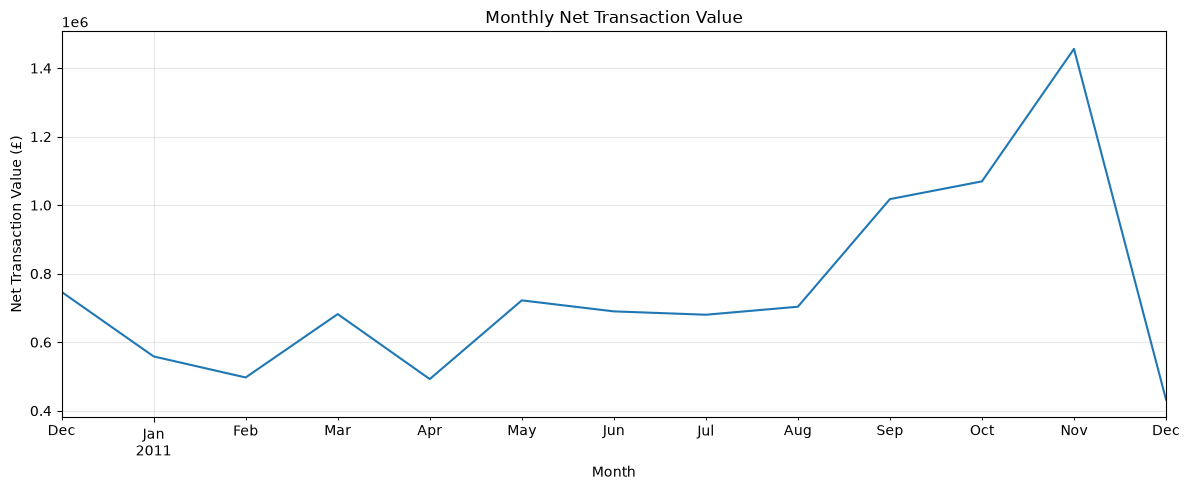

In [28]:
plt.figure(figsize=(12, 5))

monthly_sales.plot()

plt.title("Monthly Net Transaction Value")
plt.xlabel("Month")
plt.ylabel("Net Transaction Value (£)")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [29]:
# December 2011 is incomplete in the source dataset,
# so exclude it when comparing complete months.

complete_months = monthly_sales[
    monthly_sales.index < "2011-12-01"
]

highest_month = complete_months.idxmax()
lowest_month = complete_months.idxmin()

highest_value = complete_months.max()
lowest_value = complete_months.min()

august_value = complete_months.loc["2011-08-31"]
november_value = complete_months.loc["2011-11-30"]

growth_aug_to_nov = (
    (november_value - august_value) / august_value * 100
)

print("===== MONTHLY PERFORMANCE ANALYSIS =====")

print(
    f"Highest complete month: "
    f"{highest_month.strftime('%B %Y')} "
    f"→ £{highest_value:,.2f}"
)

print(
    f"Lowest complete month: "
    f"{lowest_month.strftime('%B %Y')} "
    f"→ £{lowest_value:,.2f}"
)

print(
    f"\nAugust 2011:  £{august_value:,.2f}"
)

print(
    f"November 2011: £{november_value:,.2f}"
)

print(
    f"\nGrowth from August to November: "
    f"{growth_aug_to_nov:.2f}%"
)

print(
    "\nNote: December 2011 is excluded because "
    "the dataset ends on December 9, 2011."
)

===== MONTHLY PERFORMANCE ANALYSIS =====
Highest complete month: November 2011 → £1,456,145.80
Lowest complete month: April 2011 → £492,367.84

August 2011:  £703,510.58
November 2011: £1,456,145.80

Growth from August to November: 106.98%

Note: December 2011 is excluded because the dataset ends on December 9, 2011.


## 6. Geographic Sales Analysis

Transaction value is analyzed by country to understand the geographic concentration of the retailer's business.

This analysis examines:

- Total transaction value by country
- Transaction volume by country
- The UK's contribution to overall transaction value
- The combined contribution of the top countries

The analysis helps distinguish the retailer's primary market from smaller international markets.

Because the dataset is heavily concentrated in the UK, country-level comparisons should consider both total value and transaction volume rather than relying on a single metric.

In [30]:
country_sales = (
    df_clean
    .groupby("Country")["TransactionValue"]
    .agg(
        NetTransactionValue="sum",
        TransactionCount="count"
    )
    .sort_values("NetTransactionValue", ascending=False)
)

print("===== SALES BY COUNTRY =====")
display(country_sales)

===== SALES BY COUNTRY =====


,NetTransactionValue,TransactionCount
Country,,
United Kingdom,8189252.304,490298
Netherlands,284661.540,2371
EIRE,262993.380,8184
Germany,221509.470,9480
France,197317.110,8541
Australia,137009.770,1258
Switzerland,56363.050,1994
Spain,54756.030,2528
Belgium,40910.960,2069


In [31]:
top_10_countries = country_sales.head(10)

print("===== TOP 10 COUNTRIES BY NET TRANSACTION VALUE =====")
display(top_10_countries)

===== TOP 10 COUNTRIES BY NET TRANSACTION VALUE =====


,NetTransactionValue,TransactionCount
Country,,
United Kingdom,8189252.304,490298
Netherlands,284661.540,2371
EIRE,262993.380,8184
Germany,221509.470,9480
France,197317.110,8541
Australia,137009.770,1258
Switzerland,56363.050,1994
Spain,54756.030,2528
Belgium,40910.960,2069


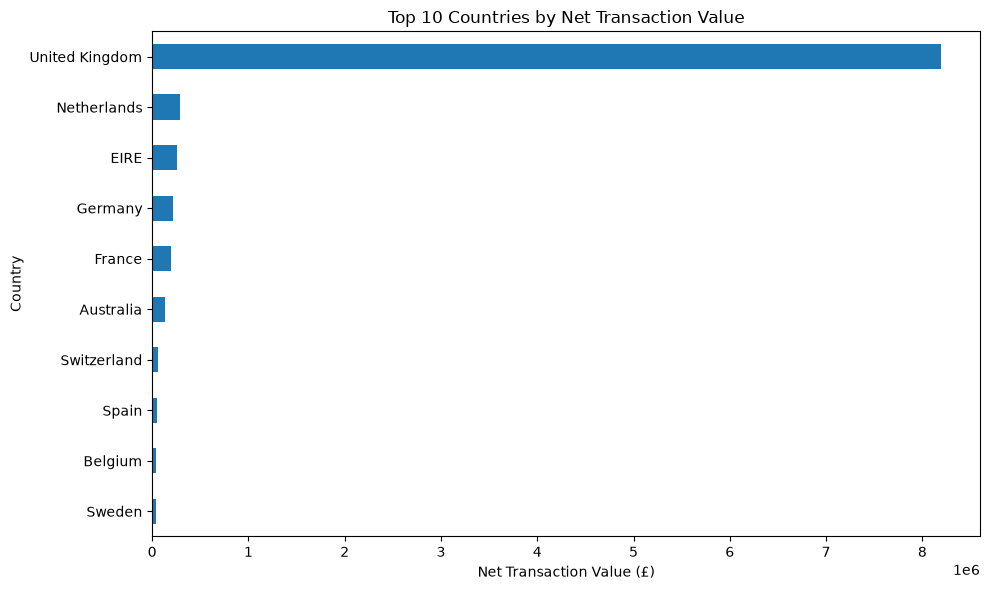

In [32]:
plt.figure(figsize=(10, 6))

top_10_countries["NetTransactionValue"].sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Countries by Net Transaction Value")
plt.xlabel("Net Transaction Value (£)")
plt.ylabel("Country")
plt.tight_layout()

plt.show()

In [33]:
total_net_value = df_clean["TransactionValue"].sum()

uk_net_value = country_sales.loc[
    "United Kingdom", "NetTransactionValue"
]

uk_share = uk_net_value / total_net_value * 100

top_5_value = country_sales.head(5)["NetTransactionValue"].sum()
top_5_share = top_5_value / total_net_value * 100

print("===== GEOGRAPHIC CONCENTRATION =====")

print(f"Total net transaction value: £{total_net_value:,.2f}")

print(
    f"\nUnited Kingdom net transaction value: "
    f"£{uk_net_value:,.2f}"
)

print(
    f"United Kingdom share of net transaction value: "
    f"{uk_share:.2f}%"
)

print(
    f"\nTop 5 countries combined value: "
    f"£{top_5_value:,.2f}"
)

print(
    f"Top 5 countries share of net transaction value: "
    f"{top_5_share:.2f}%"
)

===== GEOGRAPHIC CONCENTRATION =====
Total net transaction value: £9,748,131.07

United Kingdom net transaction value: £8,189,252.30
United Kingdom share of net transaction value: 84.01%

Top 5 countries combined value: £9,155,733.80
Top 5 countries share of net transaction value: 93.92%


In [34]:
product_sales = (
    df_clean
    .groupby(["StockCode", "Description"])["TransactionValue"]
    .agg(
        NetTransactionValue="sum",
        Quantity="sum",
        TransactionCount="count"
    )
    .sort_values("NetTransactionValue", ascending=False)
)

print("===== TOP PRODUCTS BY NET TRANSACTION VALUE =====")
display(product_sales.head(20))

===== TOP PRODUCTS BY NET TRANSACTION VALUE =====


,,NetTransactionValue,Quantity,TransactionCount
StockCode,Description,,,
DOT,DOTCOM POSTAGE,206245.48,206245.48,709
22423,REGENCY CAKESTAND 3 TIER,164459.49,164459.49,2189
47566,PARTY BUNTING,98243.88,98243.88,1720
85123A,WHITE HANGING HEART T-LIGHT HOLDER,97659.94,97659.94,2290
85099B,JUMBO BAG RED RETROSPOT,92175.79,92175.79,2156
23084,RABBIT NIGHT LIGHT,66661.63,66661.63,1032
POST,POSTAGE,66230.64,66230.64,1252
22086,PAPER CHAIN KIT 50'S CHRISTMAS,63715.24,63715.24,1194
84879,ASSORTED COLOUR BIRD ORNAMENT,58792.42,58792.42,1488


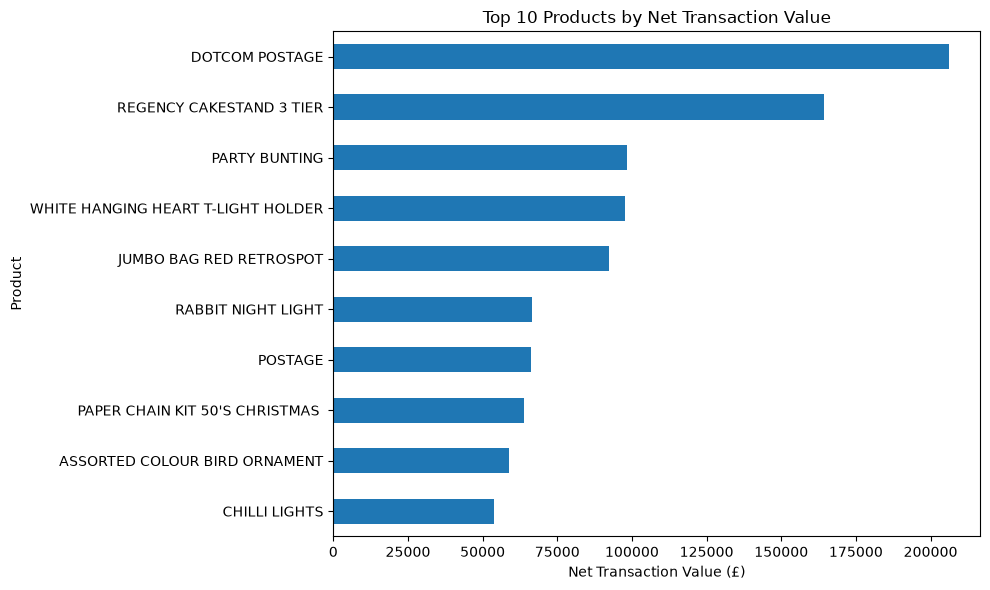

In [35]:
top_10_products = product_sales.head(10).copy()

# Create shorter labels for visualization
top_10_products["Product"] = (
    top_10_products.index.get_level_values("Description")
    .fillna("Unknown")
    .str.slice(0, 35)
)

plot_data = top_10_products.set_index("Product")[
    "NetTransactionValue"
].sort_values()

plt.figure(figsize=(10, 6))

plot_data.plot(kind="barh")

plt.title("Top 10 Products by Net Transaction Value")
plt.xlabel("Net Transaction Value (£)")
plt.ylabel("Product")
plt.tight_layout()

plt.show()

In [36]:
print("===== PRODUCT AGGREGATION VALIDATION =====")

print("Column names:")
print(product_sales.columns.tolist())

print("\nData types:")
print(product_sales.dtypes)

print("\nTop 5 products with all metrics:")
display(product_sales.head(5))

===== PRODUCT AGGREGATION VALIDATION =====
Column names:
['NetTransactionValue', 'Quantity', 'TransactionCount']

Data types:
NetTransactionValue    float64
Quantity               float64
TransactionCount         int64
dtype: object

Top 5 products with all metrics:


,,NetTransactionValue,Quantity,TransactionCount
StockCode,Description,,,
DOT,DOTCOM POSTAGE,206245.48,206245.48,709
22423,REGENCY CAKESTAND 3 TIER,164459.49,164459.49,2189
47566,PARTY BUNTING,98243.88,98243.88,1720
85123A,WHITE HANGING HEART T-LIGHT HOLDER,97659.94,97659.94,2290
85099B,JUMBO BAG RED RETROSPOT,92175.79,92175.79,2156


In [37]:
print("===== RAW TRANSACTION CHECK =====")

sample_product = "22423"

sample_rows = df_clean[
    df_clean["StockCode"].astype(str) == sample_product
]

print(f"StockCode: {sample_product}")
print(f"Description: {sample_rows['Description'].dropna().iloc[0]}")
print(f"Number of rows: {len(sample_rows):,}")
print(f"Quantity sum: {sample_rows['Quantity'].sum():,}")
print(
    f"Transaction value sum: "
    f"£{sample_rows['TransactionValue'].sum():,.2f}"
)

===== RAW TRANSACTION CHECK =====
StockCode: 22423
Description: REGENCY CAKESTAND 3 TIER
Number of rows: 2,192
Quantity sum: 12,954
Transaction value sum: £164,459.49


In [39]:
# Identify records that may represent services, fees,
# discounts, or administrative adjustments.

non_product_keywords = (
    "POSTAGE",
    "DISCOUNT",
    "BANK CHARGES",
    "FEE",
    "COMMISSION",
    "MANUAL",
    "ADJUST",
    "SAMPLES"
)

non_product_mask = (
    df_clean["Description"]
    .fillna("")
    .str.upper()
    .str.contains(
        "|".join(non_product_keywords),
        regex=True,
        na=False
    )
)

non_product_summary = (
    df_clean[non_product_mask]
    .groupby("Description")["TransactionValue"]
    .agg(
        NetTransactionValue="sum",
        Quantity="sum",
        TransactionCount="count"
    )
    .sort_values("NetTransactionValue", ascending=False)
)

print("===== POTENTIAL NON-PRODUCT TRANSACTIONS =====")
print(f"Rows identified: {non_product_mask.sum():,}")
print(
    f"Unique descriptions: "
    f"{df_clean.loc[non_product_mask, 'Description'].nunique():,}"
)

print("\nTop 30 descriptions:")
display(non_product_summary.head(30))

===== POTENTIAL NON-PRODUCT TRANSACTIONS =====
Rows identified: 6,352
Unique descriptions: 55

Top 30 descriptions:


,NetTransactionValue,Quantity,TransactionCount
Description,,,
DOTCOM POSTAGE,206245.48,206245.48,709
POSTAGE,66230.64,66230.64,1252
SET OF TEA COFFEE SUGAR TINS PANTRY,22943.87,22943.87,506
"SET 3 RETROSPOT TEA,COFFEE,SUGAR",11304.31,11304.31,444
Adjust bad debt,11062.06,11062.06,1
LONDON BUS COFFEE MUG,10107.00,10107.00,322
COFFEE MUG APPLES DESIGN,6167.10,6167.10,272
QUEENS GUARD COFFEE MUG,5811.64,5811.64,279
COFFEE MUG PEARS DESIGN,5103.69,5103.69,216


In [40]:
print("===== NON-PRODUCT CANDIDATE RECORDS =====")

candidate_records = (
    df_clean[non_product_mask]
    [
        [
            "StockCode",
            "Description",
            "Quantity",
            "UnitPrice",
            "TransactionValue"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        ["StockCode", "Description"],
        na_position="last"
    )
)

print(f"Unique StockCode/Description combinations: {len(candidate_records):,}")

display(candidate_records)

===== NON-PRODUCT CANDIDATE RECORDS =====
Unique StockCode/Description combinations: 2,023


,StockCode,Description,Quantity,UnitPrice,TransactionValue
414724,20665,adjustment,-15,0.00,-0.00
9103,20748,KENSINGTON COFFEE SET,1,12.75,12.75
26146,20748,KENSINGTON COFFEE SET,3,12.75,38.25
51021,20748,KENSINGTON COFFEE SET,5,12.75,63.75
80141,20748,KENSINGTON COFFEE SET,2,12.75,25.50
...,...,...,...,...,...
419666,S,SAMPLES,1,33.05,33.05
480961,S,SAMPLES,-1,2.89,-2.89
480962,S,SAMPLES,-1,75.00,-75.00
480963,S,SAMPLES,-1,5.99,-5.99


In [41]:
print("===== NON-STANDARD STOCK CODES =====")

# Convert StockCode to string for inspection
stockcode_text = df_clean["StockCode"].astype(str).str.strip()

# Identify stock codes containing no digits
non_standard_mask = ~stockcode_text.str.contains(r"\d", regex=True, na=False)

non_standard_summary = (
    df_clean[non_standard_mask]
    .groupby(["StockCode", "Description"])["TransactionValue"]
    .agg(
        NetTransactionValue="sum",
        Quantity="sum",
        TransactionCount="count"
    )
    .sort_values("TransactionCount", ascending=False)
)

print(
    f"Rows with StockCodes containing no digits: "
    f"{non_standard_mask.sum():,}"
)

print(
    f"Unique StockCode/Description combinations: "
    f"{len(non_standard_summary):,}"
)

display(non_standard_summary)

===== NON-STANDARD STOCK CODES =====
Rows with StockCodes containing no digits: 2,788
Unique StockCode/Description combinations: 13


,,NetTransactionValue,Quantity,TransactionCount
StockCode,Description,,,
POST,POSTAGE,66230.640,66230.640,1252
DOT,DOTCOM POSTAGE,206245.480,206245.480,709
M,Manual,-69034.190,-69034.190,566
D,Discount,-5696.220,-5696.220,77
S,SAMPLES,-3039.650,-3039.650,62
BANK CHARGES,Bank Charges,-7175.639,-7175.639,37
AMAZONFEE,AMAZON FEE,-221520.500,-221520.500,34
CRUK,CRUK Commission,-7933.430,-7933.430,16
DCGSSGIRL,GIRLS PARTY BAG,144.430,144.430,13


## 7. Product Performance Analysis

Product-level analysis requires separating physical products from non-product transaction codes such as postage, discounts, bank charges, commissions, and accounting adjustments.

The analysis therefore excludes identified non-product StockCodes before evaluating product performance.

The product analysis focuses on:

- Products generating the highest transaction value
- Products with the highest quantities sold
- Return behavior by product
- Products with unusually high return shares

High return shares are interpreted carefully because some products contain correction or zero-value transactions. A high return ratio does not automatically indicate poor product quality or customer dissatisfaction.

In [42]:
print("===== DEFINING PRODUCT ANALYSIS RULE =====")

non_product_stockcodes = [
    "POST",
    "DOT",
    "M",
    "m",
    "D",
    "S",
    "BANK CHARGES",
    "AMAZON",
    "CRUK",
    "B"
]

product_analysis_mask = ~df_clean["StockCode"].astype(str).str.strip().isin(
    non_product_stockcodes
)

df_product = df_clean[product_analysis_mask].copy()

print(f"Original cleaned rows: {len(df_clean):,}")
print(f"Rows excluded from product analysis: {len(df_clean) - len(df_product):,}")
print(f"Rows retained for product analysis: {len(df_product):,}")

print("\nExcluded StockCodes:")
print(
    df_clean.loc[
        ~product_analysis_mask,
        "StockCode"
    ]
    .value_counts()
)

print("\nProduct-analysis dataset preview:")
display(df_product.head())

===== DEFINING PRODUCT ANALYSIS RULE =====
Original cleaned rows: 536,639
Rows excluded from product analysis: 2,726
Rows retained for product analysis: 533,913

Excluded StockCodes:
StockCode
POST            1256
DOT              710
M                566
D                 77
S                 62
BANK CHARGES      37
CRUK              16
m                  1
B                  1
Name: count, dtype: int64

Product-analysis dataset preview:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TransactionType,TransactionValue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,Sale,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Sale,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,Sale,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Sale,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Sale,20.34


In [43]:
product_sales = (
    df_product
    .groupby(["StockCode", "Description"])["TransactionValue"]
    .agg(
        NetTransactionValue="sum",
        Quantity="sum",
        TransactionCount="count"
    )
    .sort_values("NetTransactionValue", ascending=False)
)

print("===== TOP 20 PHYSICAL PRODUCTS =====")
display(product_sales.head(20))

===== TOP 20 PHYSICAL PRODUCTS =====


,,NetTransactionValue,Quantity,TransactionCount
StockCode,Description,,,
22423,REGENCY CAKESTAND 3 TIER,164459.49,164459.49,2189
47566,PARTY BUNTING,98243.88,98243.88,1720
85123A,WHITE HANGING HEART T-LIGHT HOLDER,97659.94,97659.94,2290
85099B,JUMBO BAG RED RETROSPOT,92175.79,92175.79,2156
23084,RABBIT NIGHT LIGHT,66661.63,66661.63,1032
22086,PAPER CHAIN KIT 50'S CHRISTMAS,63715.24,63715.24,1194
84879,ASSORTED COLOUR BIRD ORNAMENT,58792.42,58792.42,1488
79321,CHILLI LIGHTS,53746.66,53746.66,676
23298,SPOTTY BUNTING,42030.67,42030.67,1168


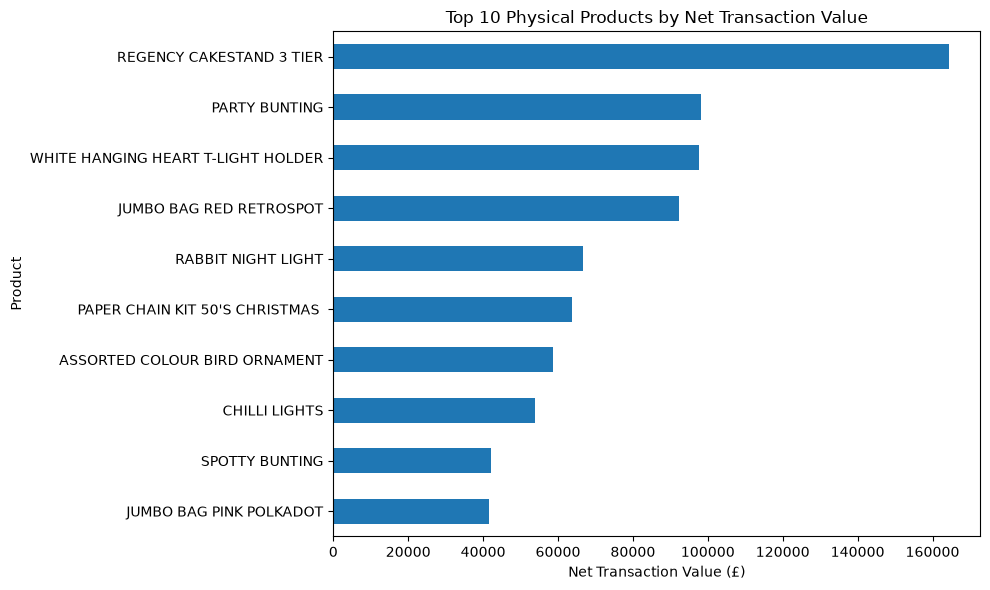

In [44]:
top_10_products = product_sales.head(10).copy()

top_10_products["Product"] = (
    top_10_products.index
    .get_level_values("Description")
    .fillna("Unknown")
    .str.slice(0, 35)
)

plot_data = (
    top_10_products
    .set_index("Product")["NetTransactionValue"]
    .sort_values()
)

plt.figure(figsize=(10, 6))

plot_data.plot(kind="barh")

plt.title("Top 10 Physical Products by Net Transaction Value")
plt.xlabel("Net Transaction Value (£)")
plt.ylabel("Product")
plt.tight_layout()

plt.show()

In [45]:
product_quantity = (
    df_product
    .groupby(["StockCode", "Description"])["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

print("===== TOP 20 PRODUCTS BY QUANTITY SOLD =====")
display(product_quantity.head(20))

===== TOP 20 PRODUCTS BY QUANTITY SOLD =====


StockCode  Description                       
84077      WORLD WAR 2 GLIDERS ASSTD DESIGNS     53751
85099B     JUMBO BAG RED RETROSPOT               47260
22197      POPCORN HOLDER                        36322
84879      ASSORTED COLOUR BIRD ORNAMENT         36282
21212      PACK OF 72 RETROSPOT CAKE CASES       36016
85123A     WHITE HANGING HEART T-LIGHT HOLDER    35006
23084      RABBIT NIGHT LIGHT                    30631
22492      MINI PAINT SET VINTAGE                26437
22616      PACK OF 12 LONDON TISSUES             26299
21977      PACK OF 60 PINK PAISLEY CAKE CASES    24719
22178      VICTORIAN GLASS HANGING T-LIGHT       23825
15036      ASSORTED COLOURS SILK FAN             23082
17003      BROCADE RING PURSE                    23017
21915      RED  HARMONICA IN BOX                 21836
22386      JUMBO BAG PINK POLKADOT               20992
22197      SMALL POPCORN HOLDER                  20105
22086      PAPER CHAIN KIT 50'S CHRISTMAS        18876
20725      LUNCH BA

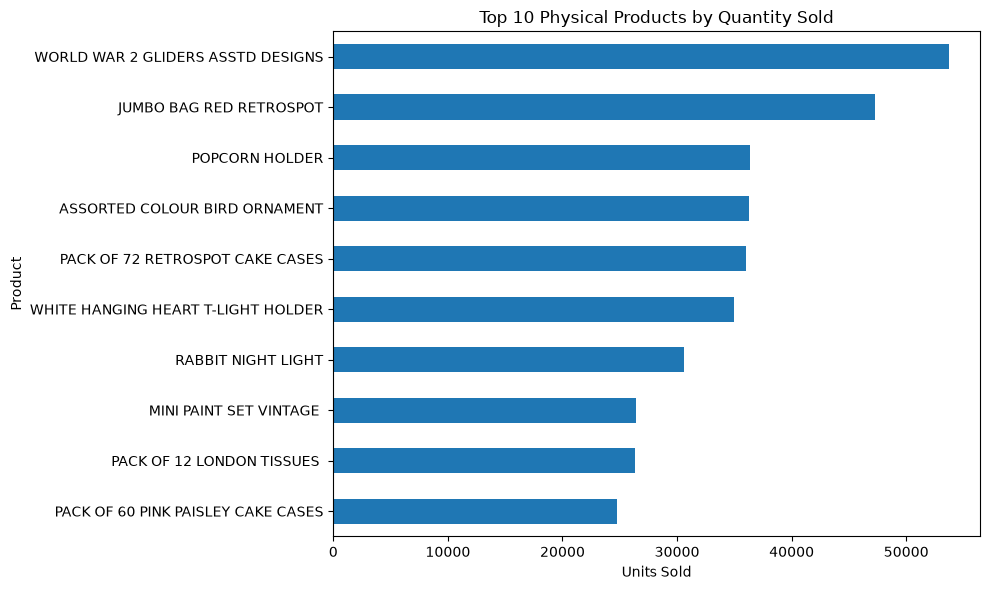

In [46]:
top_10_quantity = product_quantity.head(10).copy()

top_10_quantity.index = (
    top_10_quantity.index
    .get_level_values("Description")
    .fillna("Unknown")
    .str.slice(0, 35)
)

top_10_quantity = top_10_quantity.sort_values()

plt.figure(figsize=(10, 6))

top_10_quantity.plot(kind="barh")

plt.title("Top 10 Physical Products by Quantity Sold")
plt.xlabel("Units Sold")
plt.ylabel("Product")
plt.tight_layout()

plt.show()

In [47]:
product_return_analysis = (
    df_product
    .groupby(["StockCode", "Description"])
    .agg(
        SoldUnits=("Quantity", lambda x: x[x > 0].sum()),
        ReturnedUnits=("Quantity", lambda x: abs(x[x < 0].sum())),
        TransactionCount=("TransactionValue", "count"),
        NetTransactionValue=("TransactionValue", "sum")
    )
)

product_return_analysis["ReturnRate"] = (
    product_return_analysis["ReturnedUnits"]
    / product_return_analysis["SoldUnits"]
)

product_return_analysis = (
    product_return_analysis[
        product_return_analysis["SoldUnits"] >= 100
    ]
    .sort_values("ReturnRate", ascending=False)
)

print("===== PRODUCTS WITH HIGHEST RETURN RATES =====")
display(product_return_analysis.head(20))

===== PRODUCTS WITH HIGHEST RETURN RATES =====


,,SoldUnits,ReturnedUnits,TransactionCount,NetTransactionValue,ReturnRate
StockCode,Description,,,,,
23343,wrongly coded 20713,800,1000,2,0.00,1.250000
47566B,incorrectly credited C550456 see 47,1300,1300,2,0.00,1.000000
23843,"PAPER CRAFT , LITTLE BIRDIE",80995,80995,2,0.00,1.000000
84347,ROTATING SILVER ANGELS T-LIGHT HLDR,9461,9376,468,26103.98,0.991016
23166,MEDIUM CERAMIC TOP STORAGE JAR,78033,74494,260,4221.28,0.954647
85232B,SET OF 3 BABUSHKA STACKING TINS,274,255,19,98.25,0.930657
23113,PANTRY CHOPPING BOARD,1154,946,63,1065.44,0.819757
85023B,EAU DE NILE JEWELLED PHOTOFRAME,105,73,15,81.60,0.695238
23055,IVORY CHANDELIER T-LIGHT HOLDER,657,432,45,704.46,0.657534


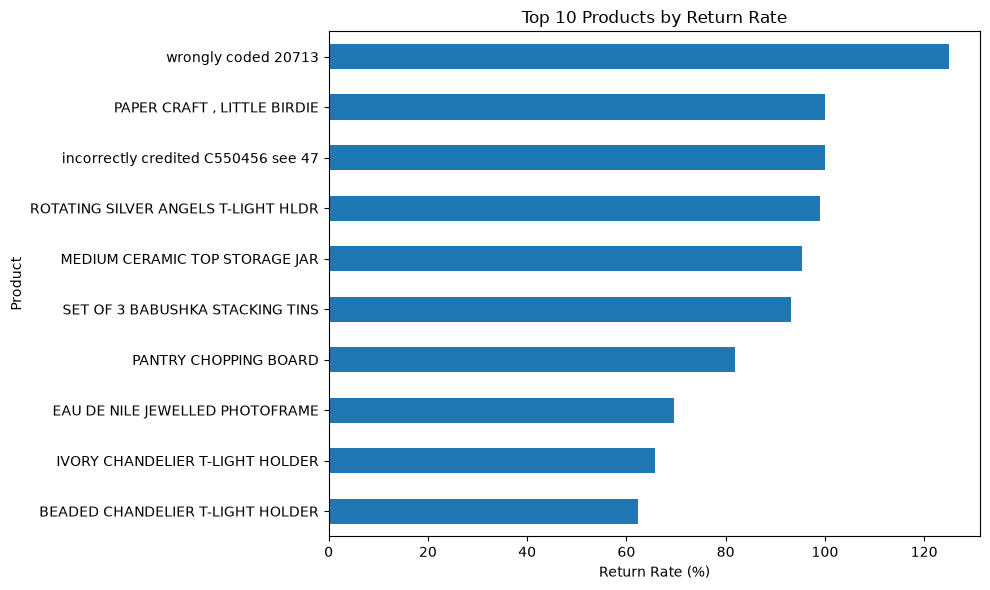

In [48]:
top_10_return_rate = product_return_analysis.head(10).copy()

top_10_return_rate.index = (
    top_10_return_rate.index
    .get_level_values("Description")
    .fillna("Unknown")
    .str.slice(0, 35)
)

plot_return_rate = (
    top_10_return_rate["ReturnRate"] * 100
).sort_values()

plt.figure(figsize=(10, 6))

plot_return_rate.plot(kind="barh")

plt.title("Top 10 Products by Return Rate")
plt.xlabel("Return Rate (%)")
plt.ylabel("Product")
plt.tight_layout()

plt.show()

In [49]:
print("===== INVESTIGATING HIGH RETURN-RATE PRODUCTS =====")

high_return_products = product_return_analysis[
    product_return_analysis["ReturnRate"] > 0.50
].copy()

print(f"Products with return rate above 50%: {len(high_return_products):,}")

display(high_return_products.head(30))

===== INVESTIGATING HIGH RETURN-RATE PRODUCTS =====
Products with return rate above 50%: 12


,,SoldUnits,ReturnedUnits,TransactionCount,NetTransactionValue,ReturnRate
StockCode,Description,,,,,
23343,wrongly coded 20713,800,1000,2,0.00,1.250000
47566B,incorrectly credited C550456 see 47,1300,1300,2,0.00,1.000000
23843,"PAPER CRAFT , LITTLE BIRDIE",80995,80995,2,0.00,1.000000
84347,ROTATING SILVER ANGELS T-LIGHT HLDR,9461,9376,468,26103.98,0.991016
23166,MEDIUM CERAMIC TOP STORAGE JAR,78033,74494,260,4221.28,0.954647
85232B,SET OF 3 BABUSHKA STACKING TINS,274,255,19,98.25,0.930657
23113,PANTRY CHOPPING BOARD,1154,946,63,1065.44,0.819757
85023B,EAU DE NILE JEWELLED PHOTOFRAME,105,73,15,81.60,0.695238
23055,IVORY CHANDELIER T-LIGHT HOLDER,657,432,45,704.46,0.657534


In [50]:
investigation_descriptions = [
    "wrongly coded 20713",
    "incorrectly credited C550456 see 47",
    "PAPER CRAFT , LITTLE BIRDIE",
    "ROTATING SILVER ANGELS T-LIGHT HLDR",
    "MEDIUM CERAMIC TOP STORAGE JAR"
]

investigation_rows = df_product[
    df_product["Description"].isin(investigation_descriptions)
].sort_values(
    ["Description", "InvoiceDate", "InvoiceNo"]
)

print("===== TRANSACTIONS BEHIND HIGH RETURN-RATE PRODUCTS =====")
display(investigation_rows[
    [
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "InvoiceDate",
        "UnitPrice",
        "CustomerID",
        "Country",
        "TransactionType",
        "TransactionValue"
    ]
])

===== TRANSACTIONS BEHIND HIGH RETURN-RATE PRODUCTS =====


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TransactionType,TransactionValue
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,Sale,77183.60
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,2011-01-18 10:17:00,1.04,12346.0,United Kingdom,Return/Cancellation,-77183.60
186770,552882,23166,MEDIUM CERAMIC TOP STORAGE JAR,96,2011-05-12 10:10:00,1.04,14646.0,Netherlands,Sale,99.84
187196,552953,23166,MEDIUM CERAMIC TOP STORAGE JAR,4,2011-05-12 12:11:00,1.25,16745.0,United Kingdom,Sale,5.00
187718,553005,23166,MEDIUM CERAMIC TOP STORAGE JAR,5,2011-05-12 16:29:00,1.25,14651.0,United Kingdom,Sale,6.25
...,...,...,...,...,...,...,...,...,...,...
541828,581579,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,24,2011-12-09 12:19:00,2.55,17581.0,United Kingdom,Sale,61.20
203751,554550,47566B,incorrectly credited C550456 see 47,1300,2011-05-25 09:57:00,0.00,NaN,United Kingdom,Sale,0.00
203761,554553,47566B,incorrectly credited C550456 see 47,-1300,2011-05-25 09:59:00,0.00,NaN,United Kingdom,Return/Cancellation,-0.00
380687,569830,23343,wrongly coded 20713,800,2011-10-06 12:38:00,0.00,NaN,United Kingdom,Sale,0.00


In [51]:
print("===== FINAL PRODUCT RETURN-RATE ANALYSIS =====")

# Exclude zero-price records from return-rate analysis.
# These include administrative/correction records rather than normal sales.
df_return_analysis = df_product[
    df_product["UnitPrice"] > 0
].copy()

product_return_final = (
    df_return_analysis
    .groupby(["StockCode", "Description"])
    .agg(
        SoldUnits=("Quantity", lambda x: x[x > 0].sum()),
        ReturnedUnits=("Quantity", lambda x: abs(x[x < 0].sum())),
        TransactionCount=("TransactionValue", "count"),
        NetTransactionValue=("TransactionValue", "sum")
    )
)

# Keep products with meaningful sales volume
product_return_final = product_return_final[
    product_return_final["SoldUnits"] >= 100
].copy()

# Bounded return-share metric
product_return_final["ReturnShare"] = (
    product_return_final["ReturnedUnits"]
    / (
        product_return_final["SoldUnits"]
        + product_return_final["ReturnedUnits"]
    )
)

product_return_final = product_return_final.sort_values(
    "ReturnShare",
    ascending=False
)

print("Top 20 products by return share:")
display(product_return_final.head(20))

===== FINAL PRODUCT RETURN-RATE ANALYSIS =====
Top 20 products by return share:


,,SoldUnits,ReturnedUnits,TransactionCount,NetTransactionValue,ReturnShare
StockCode,Description,,,,,
23843,"PAPER CRAFT , LITTLE BIRDIE",80995,80995,2,0.00,0.500000
84347,ROTATING SILVER ANGELS T-LIGHT HLDR,9461,9376,468,26103.98,0.497744
23166,MEDIUM CERAMIC TOP STORAGE JAR,78033,74494,260,4221.28,0.488399
85232B,SET OF 3 BABUSHKA STACKING TINS,274,255,19,98.25,0.482042
23113,PANTRY CHOPPING BOARD,1154,946,63,1065.44,0.450476
85023B,EAU DE NILE JEWELLED PHOTOFRAME,105,73,15,81.60,0.410112
23055,IVORY CHANDELIER T-LIGHT HOLDER,657,432,45,704.46,0.396694
23057,BEADED CHANDELIER T-LIGHT HOLDER,695,433,44,784.82,0.383865
23056,FLOWERS CHANDELIER T-LIGHT HOLDER,960,579,46,1020.30,0.376218


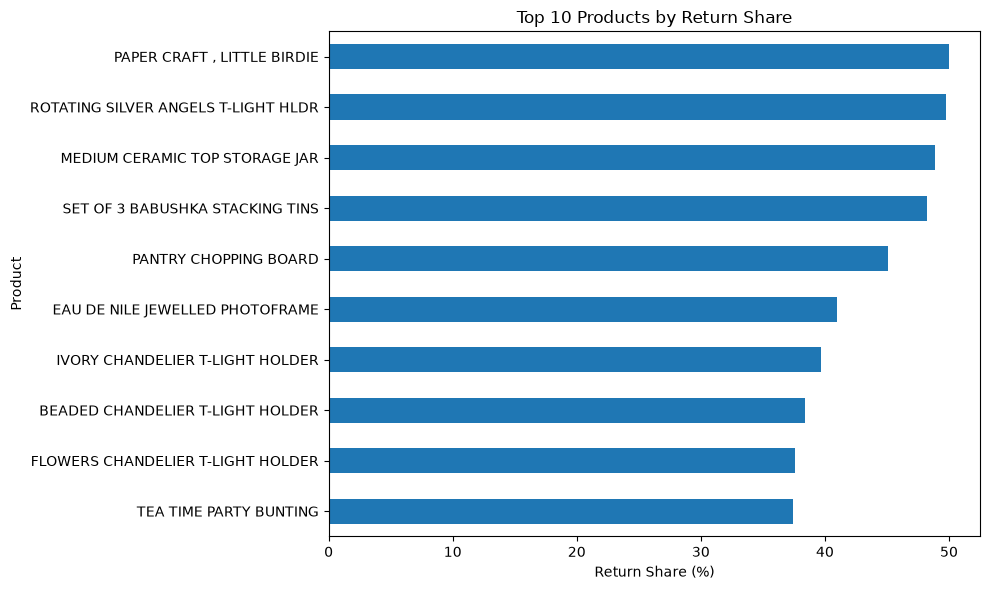

In [52]:
top_10_return_share = product_return_final.head(10).copy()

top_10_return_share.index = (
    top_10_return_share.index
    .get_level_values("Description")
    .fillna("Unknown")
    .str.slice(0, 35)
)

plot_return_share = (
    top_10_return_share["ReturnShare"] * 100
).sort_values()

plt.figure(figsize=(10, 6))

plot_return_share.plot(kind="barh")

plt.title("Top 10 Products by Return Share")
plt.xlabel("Return Share (%)")
plt.ylabel("Product")
plt.tight_layout()

plt.show()

In [53]:
print("===== OVERALL RETURN ANALYSIS =====")

total_sold_units = df_product.loc[
    df_product["Quantity"] > 0,
    "Quantity"
].sum()

total_returned_units = abs(
    df_product.loc[
        df_product["Quantity"] < 0,
        "Quantity"
    ].sum()
)

overall_return_share = (
    total_returned_units
    / (total_sold_units + total_returned_units)
)

gross_sales = df_product.loc[
    df_product["Quantity"] > 0,
    "TransactionValue"
].sum()

return_value = df_product.loc[
    df_product["Quantity"] < 0,
    "TransactionValue"
].sum()

net_transaction_value = df_product["TransactionValue"].sum()

print(f"Total units sold: {total_sold_units:,}")
print(f"Total units returned: {total_returned_units:,}")
print(f"Overall return share: {overall_return_share:.2%}")
print(f"Gross sales value: £{gross_sales:,.2f}")
print(f"Return value: £{return_value:,.2f}")
print(f"Net transaction value: £{net_transaction_value:,.2f}")

===== OVERALL RETURN ANALYSIS =====
Total units sold: 5,629,803
Total units returned: 477,008
Overall return share: 7.81%
Gross sales value: £10,268,717.22
Return value: £-711,247.75
Net transaction value: £9,557,469.47


## 8. Customer-Level Analysis

Customer-level analysis is performed only on transactions with a known `CustomerID`.

This is necessary because the raw dataset contains a substantial number of transactions with missing CustomerID values. Those records remain useful for overall sales and product analysis, but they cannot be reliably attributed to individual customers.

The customer analysis examines:

- Customer transaction value
- Purchase frequency
- Customer value concentration
- Customer contribution by country
- Customer return behavior
- Relationship between customer value and return activity

This separation ensures that customer-level metrics are calculated from a consistent and identifiable customer population.

In [54]:
print("===== CUSTOMER-LEVEL ANALYSIS =====")

df_customer = df_product[
    df_product["CustomerID"].notna()
].copy()

customer_summary = (
    df_customer
    .groupby("CustomerID")
    .agg(
        NetTransactionValue=("TransactionValue", "sum"),
        TotalUnits=("Quantity", "sum"),
        InvoiceCount=("InvoiceNo", "nunique"),
        TransactionCount=("InvoiceNo", "count")
    )
    .sort_values(
        "NetTransactionValue",
        ascending=False
    )
)

print(f"Transactions with known CustomerID: {len(df_customer):,}")
print(f"Unique customers: {customer_summary.shape[0]:,}")

print("\n===== TOP 20 CUSTOMERS BY NET TRANSACTION VALUE =====")
display(customer_summary.head(20))

===== CUSTOMER-LEVEL ANALYSIS =====
Transactions with known CustomerID: 399,827
Unique customers: 4,363

===== TOP 20 CUSTOMERS BY NET TRANSACTION VALUE =====


,NetTransactionValue,TotalUnits,InvoiceCount,TransactionCount
CustomerID,,,,
14646.0,278778.02,197132,74,2066
18102.0,259657.30,64124,60,431
17450.0,189575.53,69021,49,339
14911.0,132893.24,77156,243,5893
12415.0,123638.18,77242,24,776
14156.0,114335.77,56909,65,1414
17511.0,88138.20,63014,45,1074
16684.0,65920.12,49391,30,280
13694.0,62961.54,61904,57,581


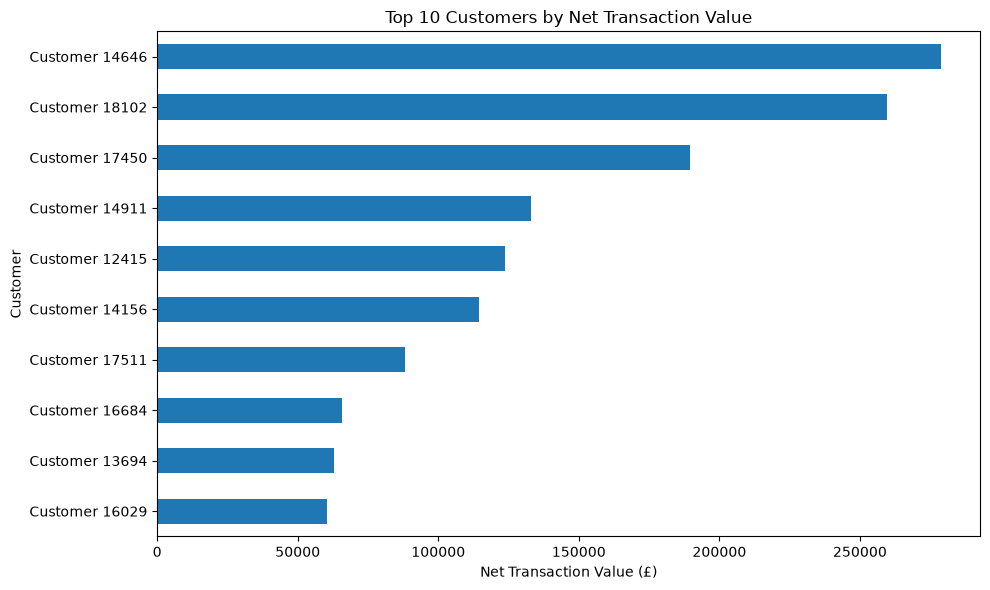

In [55]:
top_10_customers = customer_summary.head(10).copy()

top_10_customers["Customer"] = (
    "Customer " +
    top_10_customers.index.astype(int).astype(str)
)

plot_customer_value = (
    top_10_customers
    .set_index("Customer")["NetTransactionValue"]
    .sort_values()
)

plt.figure(figsize=(10, 6))

plot_customer_value.plot(kind="barh")

plt.title("Top 10 Customers by Net Transaction Value")
plt.xlabel("Net Transaction Value (£)")
plt.ylabel("Customer")
plt.tight_layout()

plt.show()

In [56]:
print("===== CUSTOMER REVENUE CONCENTRATION =====")

customer_values = (
    customer_summary["NetTransactionValue"]
    .sort_values(ascending=False)
)

total_customer_value = customer_values.sum()
customer_count = len(customer_values)

concentration_results = []

for percentage in [1, 5, 10, 20]:
    n_customers = max(1, int(customer_count * percentage / 100))
    
    top_value = customer_values.head(n_customers).sum()
    
    share = top_value / total_customer_value
    
    concentration_results.append({
        "CustomerGroup": f"Top {percentage}%",
        "Customers": n_customers,
        "NetTransactionValue": top_value,
        "RevenueShare": share
    })

concentration_df = pd.DataFrame(concentration_results)

print(f"Total identifiable customers: {customer_count:,}")
print(
    f"Total identifiable-customer transaction value: "
    f"£{total_customer_value:,.2f}"
)

display(concentration_df)

===== CUSTOMER REVENUE CONCENTRATION =====
Total identifiable customers: 4,363
Total identifiable-customer transaction value: £8,272,112.93


,CustomerGroup,Customers,NetTransactionValue,RevenueShare
0,Top 1%,43,2498420.840,0.302029
1,Top 5%,218,4052203.510,0.489863
2,Top 10%,436,4990796.100,0.603328
3,Top 20%,872,6120098.491,0.739847


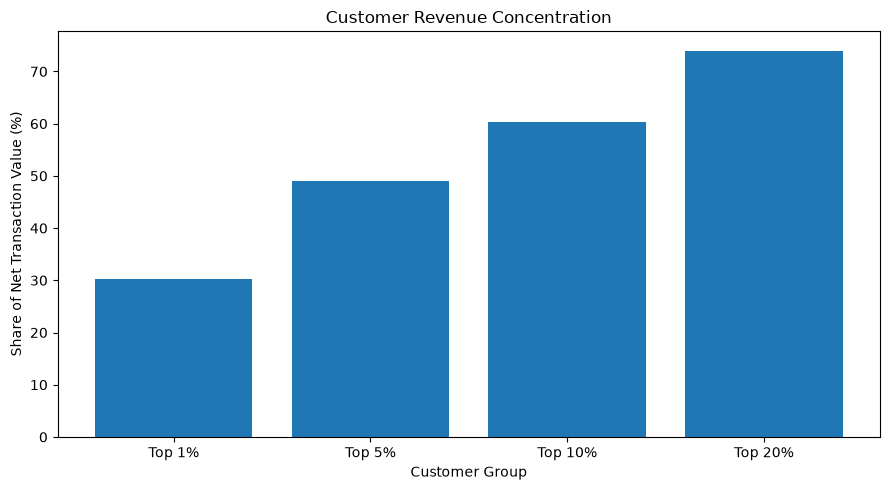

In [57]:
plot_concentration = concentration_df.copy()

plot_concentration["RevenueSharePercent"] = (
    plot_concentration["RevenueShare"] * 100
)

plt.figure(figsize=(9, 5))

plt.bar(
    plot_concentration["CustomerGroup"],
    plot_concentration["RevenueSharePercent"]
)

plt.title("Customer Revenue Concentration")
plt.xlabel("Customer Group")
plt.ylabel("Share of Net Transaction Value (%)")

plt.tight_layout()

plt.show()

In [58]:
print("===== CUSTOMER VALUE BY COUNTRY =====")

customer_country_summary = (
    df_customer
    .groupby("Country")
    .agg(
        NetTransactionValue=("TransactionValue", "sum"),
        CustomerCount=("CustomerID", "nunique"),
        TransactionCount=("InvoiceNo", "count")
    )
    .sort_values(
        "NetTransactionValue",
        ascending=False
    )
)

print("Top 20 countries by identifiable-customer transaction value:")

display(customer_country_summary.head(20))

===== CUSTOMER VALUE BY COUNTRY =====
Top 20 countries by identifiable-customer transaction value:


,NetTransactionValue,CustomerCount,TransactionCount
Country,,,
United Kingdom,6804020.583,3943,356144
Netherlands,283479.540,9,2330
EIRE,251557.470,3,7469
Germany,200619.660,95,9081
France,181571.540,87,8154
Australia,136922.500,9,1256
Switzerland,51859.400,21,1844
Spain,51746.650,30,2463
Belgium,36662.960,25,1971


In [59]:
print("===== AVERAGE CUSTOMER VALUE BY COUNTRY =====")

country_customer_value = customer_country_summary.copy()

country_customer_value["AverageCustomerValue"] = (
    country_customer_value["NetTransactionValue"]
    / country_customer_value["CustomerCount"]
)

# Require at least 5 identifiable customers
country_customer_value_filtered = (
    country_customer_value[
        country_customer_value["CustomerCount"] >= 5
    ]
    .sort_values(
        "AverageCustomerValue",
        ascending=False
    )
)

print(
    "Countries with the highest average customer value "
    "(minimum 5 identifiable customers):"
)

display(country_customer_value_filtered.head(20))

===== AVERAGE CUSTOMER VALUE BY COUNTRY =====
Countries with the highest average customer value (minimum 5 identifiable customers):


,NetTransactionValue,CustomerCount,TransactionCount,AverageCustomerValue
Country,,,,
Netherlands,283479.540,9,2330,31497.726667
Australia,136922.500,9,1256,15213.611111
Japan,35419.790,8,355,4427.473750
Sweden,35166.410,8,436,4395.801250
Norway,32292.960,10,1060,3229.296000
Switzerland,51859.400,21,1844,2469.495238
Channel Islands,20076.390,9,755,2230.710000
Germany,200619.660,95,9081,2111.785895
France,181571.540,87,8154,2087.029195


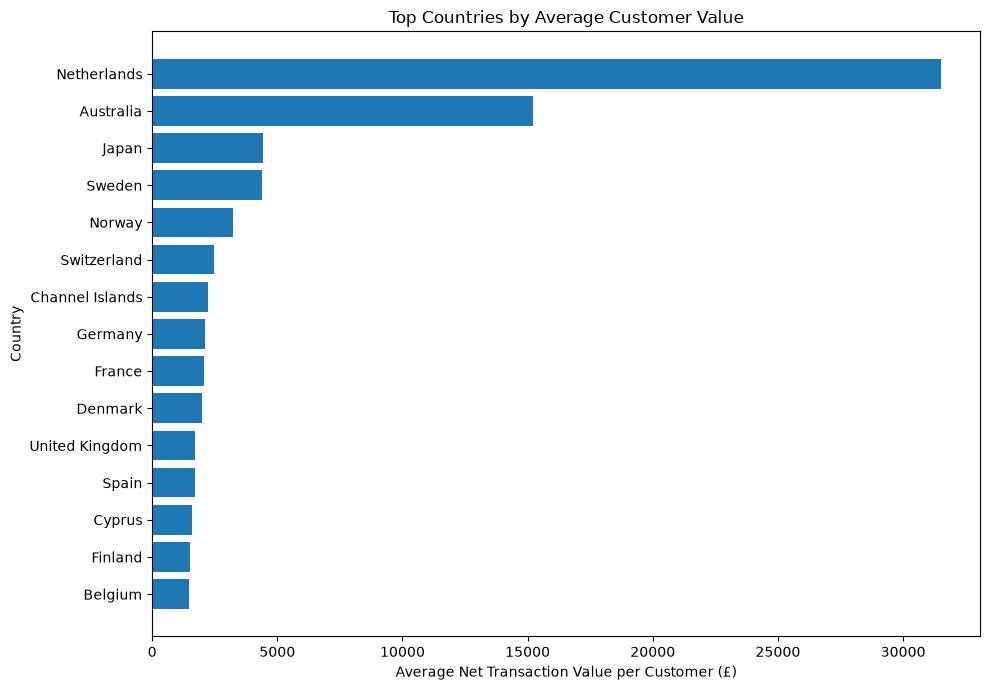

In [60]:
top_country_customer_value = (
    country_customer_value_filtered
    .head(15)
    .sort_values("AverageCustomerValue")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_country_customer_value.index,
    top_country_customer_value["AverageCustomerValue"]
)

plt.title("Top Countries by Average Customer Value")
plt.xlabel("Average Net Transaction Value per Customer (£)")
plt.ylabel("Country")

plt.tight_layout()

plt.show()

## 9. Customer Purchase Frequency

Customers are segmented according to the number of unique invoices associated with their transactions.

The groups are:

- **One-time:** 1 invoice
- **Occasional:** 2–4 invoices
- **Repeat:** 5–9 invoices
- **Frequent:** 10+ invoices

This segmentation helps identify whether transaction value is primarily driven by a large number of occasional customers or by a smaller group of highly engaged customers.

The analysis compares both customer counts and transaction-value contribution across these groups.

In [61]:
print("===== CUSTOMER PURCHASE FREQUENCY =====")

customer_frequency = customer_summary.copy()

customer_frequency["PurchaseFrequencyGroup"] = pd.cut(
    customer_frequency["InvoiceCount"],
    bins=[0, 1, 4, 9, float("inf")],
    labels=[
        "One-time (1 invoice)",
        "Occasional (2-4 invoices)",
        "Repeat (5-9 invoices)",
        "Frequent (10+ invoices)"
    ]
)

frequency_summary = (
    customer_frequency
    .groupby(
        "PurchaseFrequencyGroup",
        observed=False
    )
    .agg(
        CustomerCount=("InvoiceCount", "count"),
        NetTransactionValue=("NetTransactionValue", "sum"),
        AverageCustomerValue=("NetTransactionValue", "mean")
    )
)

frequency_summary["CustomerShare"] = (
    frequency_summary["CustomerCount"]
    / frequency_summary["CustomerCount"].sum()
)

frequency_summary["RevenueShare"] = (
    frequency_summary["NetTransactionValue"]
    / frequency_summary["NetTransactionValue"].sum()
)

display(frequency_summary)

===== CUSTOMER PURCHASE FREQUENCY =====


,CustomerCount,NetTransactionValue,AverageCustomerValue,CustomerShare,RevenueShare
PurchaseFrequencyGroup,,,,,
One-time (1 invoice),1328,440084.301,331.388781,0.304378,0.053201
Occasional (2-4 invoices),1683,1406455.321,835.683494,0.385744,0.170024
Repeat (5-9 invoices),828,1618772.471,1955.039216,0.189778,0.195690
Frequent (10+ invoices),524,4806800.840,9173.284046,0.120101,0.581085


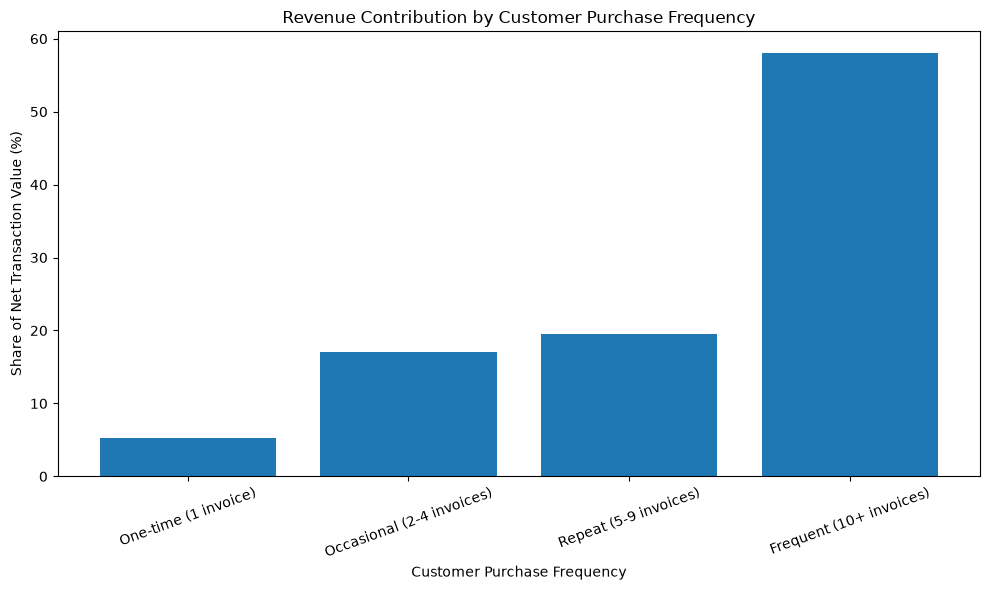

In [62]:
frequency_plot = frequency_summary.copy()

frequency_plot["RevenueSharePercent"] = (
    frequency_plot["RevenueShare"] * 100
)

plt.figure(figsize=(10, 6))

plt.bar(
    frequency_plot.index.astype(str),
    frequency_plot["RevenueSharePercent"]
)

plt.title("Revenue Contribution by Customer Purchase Frequency")
plt.xlabel("Customer Purchase Frequency")
plt.ylabel("Share of Net Transaction Value (%)")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

In [63]:
print("===== MONTHLY SALES VS RETURNS =====")

monthly_transaction_type = (
    df_product
    .assign(Month=df_product["InvoiceDate"].dt.to_period("M").astype(str))
    .groupby(["Month", "TransactionType"])["TransactionValue"]
    .sum()
    .unstack(fill_value=0)
)

monthly_transaction_type["NetTransactionValue"] = (
    monthly_transaction_type.get("Sale", 0)
    + monthly_transaction_type.get("Return/Cancellation", 0)
)

print("Monthly sales, returns, and net transaction value:")

display(monthly_transaction_type)

===== MONTHLY SALES VS RETURNS =====
Monthly sales, returns, and net transaction value:


TransactionType,Return/Cancellation,Sale,NetTransactionValue
Month,,,
2010-12,-70332.27,789856.280,719524.010
2011-01,-124916.78,670639.460,545722.680
2011-02,-19169.57,508081.540,488911.970
2011-03,-21642.14,690811.600,669169.460
2011-04,-33316.06,515869.661,482553.601
2011-05,-21831.46,740472.330,718640.870
2011-06,-24054.26,738233.990,714179.730
2011-07,-22288.35,688802.671,666514.321
2011-08,-45413.74,724708.160,679294.420


===== MONTHLY SALES VS RETURNS CHART =====


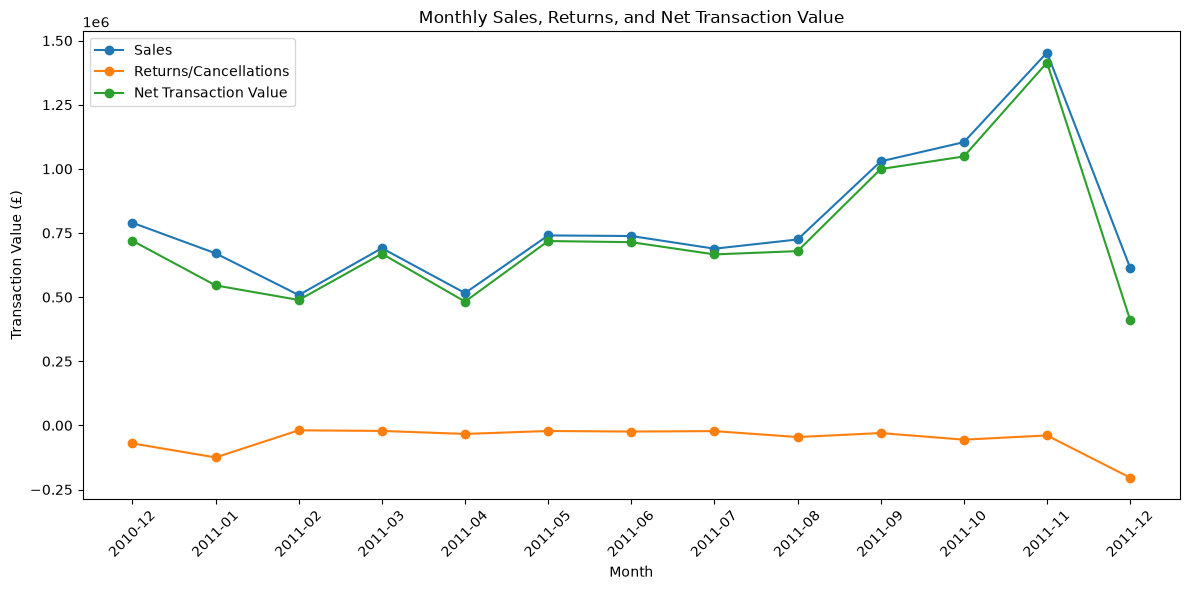

In [64]:
print("===== MONTHLY SALES VS RETURNS CHART =====")

monthly_plot = monthly_transaction_type.copy()

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_plot.index,
    monthly_plot["Sale"],
    marker="o",
    label="Sales"
)

plt.plot(
    monthly_plot.index,
    monthly_plot["Return/Cancellation"],
    marker="o",
    label="Returns/Cancellations"
)

plt.plot(
    monthly_plot.index,
    monthly_plot["NetTransactionValue"],
    marker="o",
    label="Net Transaction Value"
)

plt.title("Monthly Sales, Returns, and Net Transaction Value")
plt.xlabel("Month")
plt.ylabel("Transaction Value (£)")

plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()

plt.show()

In [65]:
print("===== MONTHLY RETURN RATE =====")

monthly_return_units = (
    df_product
    .assign(
        Month=df_product["InvoiceDate"].dt.to_period("M").astype(str),
        ReturnedUnits=np.where(
            df_product["Quantity"] < 0,
            -df_product["Quantity"],
            0
        ),
        SoldUnits=np.where(
            df_product["Quantity"] > 0,
            df_product["Quantity"],
            0
        )
    )
    .groupby("Month")
    .agg(
        SoldUnits=("SoldUnits", "sum"),
        ReturnedUnits=("ReturnedUnits", "sum")
    )
)

monthly_return_units["ReturnRate"] = (
    monthly_return_units["ReturnedUnits"]
    / monthly_return_units["SoldUnits"]
)

display(monthly_return_units)

===== MONTHLY RETURN RATE =====


,SoldUnits,ReturnedUnits,ReturnRate
Month,,,
2010-12,360617,20029,0.055541
2011-01,395676,88691,0.224151
2011-02,285775,8438,0.029527
2011-03,382623,31804,0.083121
2011-04,311025,23032,0.074052
2011-05,397551,17225,0.043328
2011-06,393263,52544,0.133610
2011-07,405083,16342,0.040342
2011-08,423952,18136,0.042778


===== MONTHLY RETURN RATE CHART =====


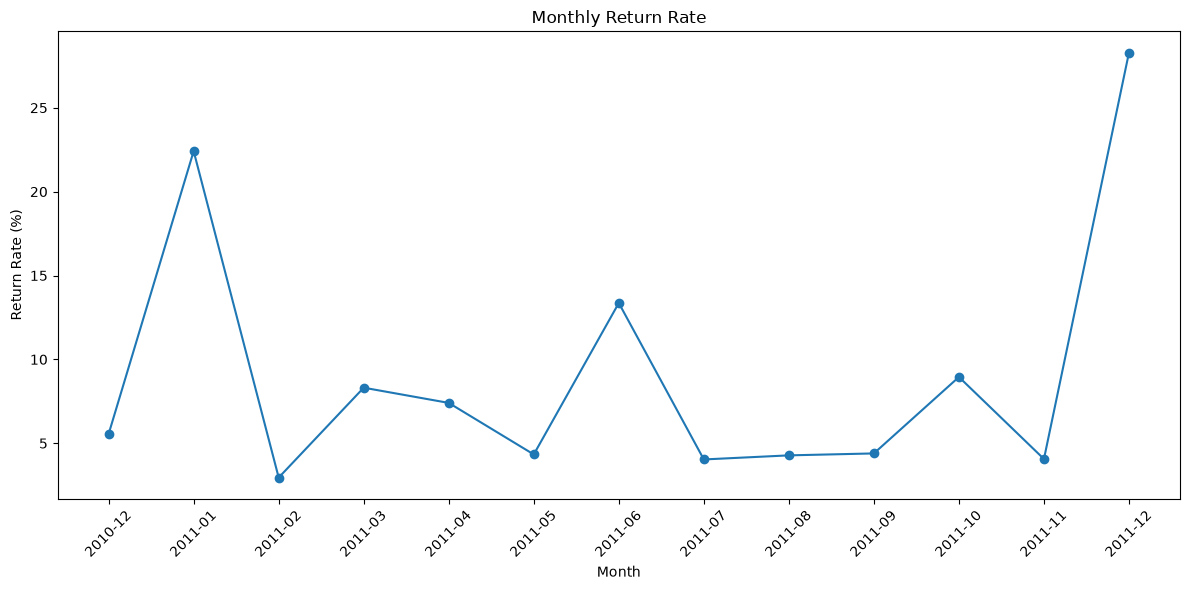

In [66]:
print("===== MONTHLY RETURN RATE CHART =====")

monthly_return_plot = monthly_return_units.copy()

monthly_return_plot["ReturnRatePercent"] = (
    monthly_return_plot["ReturnRate"] * 100
)

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_return_plot.index,
    monthly_return_plot["ReturnRatePercent"],
    marker="o"
)

plt.title("Monthly Return Rate")
plt.xlabel("Month")
plt.ylabel("Return Rate (%)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [68]:
print("===== CUSTOMER VALUE VS PURCHASE FREQUENCY =====")

customer_frequency_comparison = (
    customer_frequency
    .groupby(
        "PurchaseFrequencyGroup",
        observed=False
    )
    .agg(
        AverageCustomerValue=("NetTransactionValue", "mean"),
        MedianCustomerValue=("NetTransactionValue", "median"),
        TotalTransactionValue=("NetTransactionValue", "sum")
    )
)

customer_frequency_comparison["Customers"] = (
    customer_frequency
    .groupby(
        "PurchaseFrequencyGroup",
        observed=False
    )
    .size()
)

customer_frequency_comparison = (
    customer_frequency_comparison[
        [
            "Customers",
            "AverageCustomerValue",
            "MedianCustomerValue",
            "TotalTransactionValue"
        ]
    ]
)

display(customer_frequency_comparison)

===== CUSTOMER VALUE VS PURCHASE FREQUENCY =====


,Customers,AverageCustomerValue,MedianCustomerValue,TotalTransactionValue
PurchaseFrequencyGroup,,,,
One-time (1 invoice),1328,331.388781,232.120,440084.301
Occasional (2-4 invoices),1683,835.683494,604.640,1406455.321
Repeat (5-9 invoices),828,1955.039216,1609.220,1618772.471
Frequent (10+ invoices),524,9173.284046,4146.545,4806800.840


===== CUSTOMER VALUE BY PURCHASE FREQUENCY CHART =====


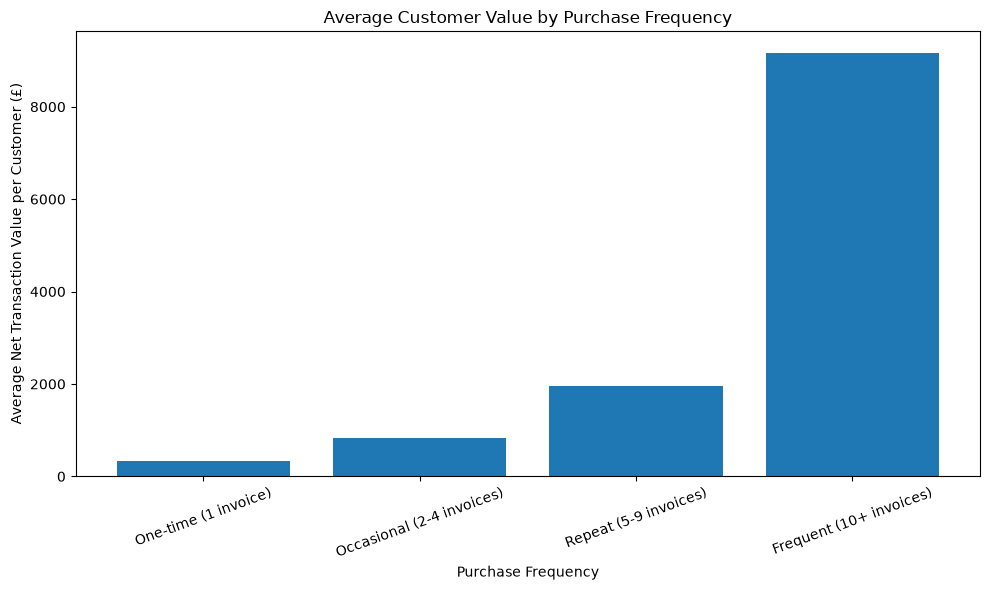

In [69]:
print("===== CUSTOMER VALUE BY PURCHASE FREQUENCY CHART =====")

frequency_order = [
    "One-time (1 invoice)",
    "Occasional (2-4 invoices)",
    "Repeat (5-9 invoices)",
    "Frequent (10+ invoices)"
]

frequency_value_plot = (
    customer_frequency_comparison
    .reindex(frequency_order)
)

plt.figure(figsize=(10, 6))

plt.bar(
    frequency_value_plot.index,
    frequency_value_plot["AverageCustomerValue"]
)

plt.title("Average Customer Value by Purchase Frequency")
plt.xlabel("Purchase Frequency")
plt.ylabel("Average Net Transaction Value per Customer (£)")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

In [70]:
print("===== CUSTOMER RETURN BEHAVIOR =====")

customer_return_analysis = (
    df_clean[df_clean["CustomerID"].notna()]
    .groupby("CustomerID")
    .agg(
        TotalUnits=("Quantity", lambda x: x[x > 0].sum()),
        ReturnedUnits=("Quantity", lambda x: -x[x < 0].sum()),
        NetTransactionValue=("TransactionValue", "sum"),
        TransactionCount=("TransactionValue", "count")
    )
)

customer_return_analysis["ReturnShare"] = (
    customer_return_analysis["ReturnedUnits"]
    / customer_return_analysis["TotalUnits"]
)

customer_return_analysis = (
    customer_return_analysis
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["ReturnShare"])
)

print(
    f"Customers with identifiable return analysis: "
    f"{len(customer_return_analysis):,}"
)

print("\n===== TOP 20 CUSTOMERS BY RETURN SHARE =====")

display(
    customer_return_analysis
    .sort_values("ReturnShare", ascending=False)
    .head(20)
)

===== CUSTOMER RETURN BEHAVIOR =====
Customers with identifiable return analysis: 4,339

===== TOP 20 CUSTOMERS BY RETURN SHARE =====


,TotalUnits,ReturnedUnits,NetTransactionValue,TransactionCount,ReturnShare
CustomerID,,,,,
15823.0,1,284,-8.407600e+02,17,284.000000
16742.0,1,190,0.000000e+00,4,190.000000
17548.0,58,190,-1.414800e+02,17,3.275862
15802.0,1,2,-4.514200e+02,3,2.000000
16546.0,549,852,-9.593000e+01,31,1.551913
17603.0,74,105,-1.165300e+03,15,1.418919
13672.0,57,58,-7.146000e+01,16,1.017544
12454.0,1006,1006,5.684342e-14,30,1.000000
13364.0,71,71,0.000000e+00,20,1.000000


In [71]:
print("===== MEANINGFUL CUSTOMER RETURN ANALYSIS =====")

customer_return_filtered = (
    customer_return_analysis[
        customer_return_analysis["TotalUnits"] >= 100
    ]
    .copy()
)

print(
    f"Customers with at least 100 units sold: "
    f"{len(customer_return_filtered):,}"
)

print("\n===== TOP 20 CUSTOMERS BY RETURN SHARE =====")

display(
    customer_return_filtered
    .sort_values("ReturnShare", ascending=False)
    .head(20)
)

===== MEANINGFUL CUSTOMER RETURN ANALYSIS =====
Customers with at least 100 units sold: 3,710

===== TOP 20 CUSTOMERS BY RETURN SHARE =====


,TotalUnits,ReturnedUnits,NetTransactionValue,TransactionCount,ReturnShare
CustomerID,,,,,
16546.0,549,852,-9.593000e+01,31,1.551913
12908.0,1200,1200,2.460000e+02,4,1.000000
12454.0,1006,1006,5.684342e-14,30,1.000000
18133.0,1350,1350,7.155000e+02,2,1.000000
13762.0,272,272,3.552714e-15,14,1.000000
12346.0,74215,74215,0.000000e+00,2,1.000000
12607.0,1228,1228,3.552714e-15,202,1.000000
14557.0,510,510,0.000000e+00,32,1.000000
12558.0,196,196,1.065814e-14,22,1.000000


In [72]:
print("===== HIGH-VALUE CUSTOMERS WITH HIGH RETURN SHARE =====")

# Determine the top-10% customer value threshold
high_value_threshold = customer_return_filtered[
    "NetTransactionValue"
].quantile(0.90)

print(
    f"Top 10% customer value threshold: "
    f"£{high_value_threshold:,.2f}"
)

high_value_return_customers = (
    customer_return_filtered[
        (customer_return_filtered["NetTransactionValue"] >= high_value_threshold)
        & (customer_return_filtered["ReturnShare"] >= 0.20)
    ]
    .sort_values(
        ["ReturnShare", "NetTransactionValue"],
        ascending=[False, False]
    )
)

print(
    f"\nHigh-value customers with return share >= 20%: "
    f"{len(high_value_return_customers):,}"
)

display(high_value_return_customers)

===== HIGH-VALUE CUSTOMERS WITH HIGH RETURN SHARE =====
Top 10% customer value threshold: £3,869.16

High-value customers with return share >= 20%: 4


,TotalUnits,ReturnedUnits,NetTransactionValue,TransactionCount,ReturnShare
CustomerID,,,,,
15838.0,18368,9361,33350.76,169,0.509636
15749.0,18028,9014,21535.90,15,0.500000
15482.0,5004,2022,6393.52,126,0.404077
14607.0,11526,3768,10981.10,109,0.326913


===== CUSTOMER VALUE VS RETURN SHARE =====


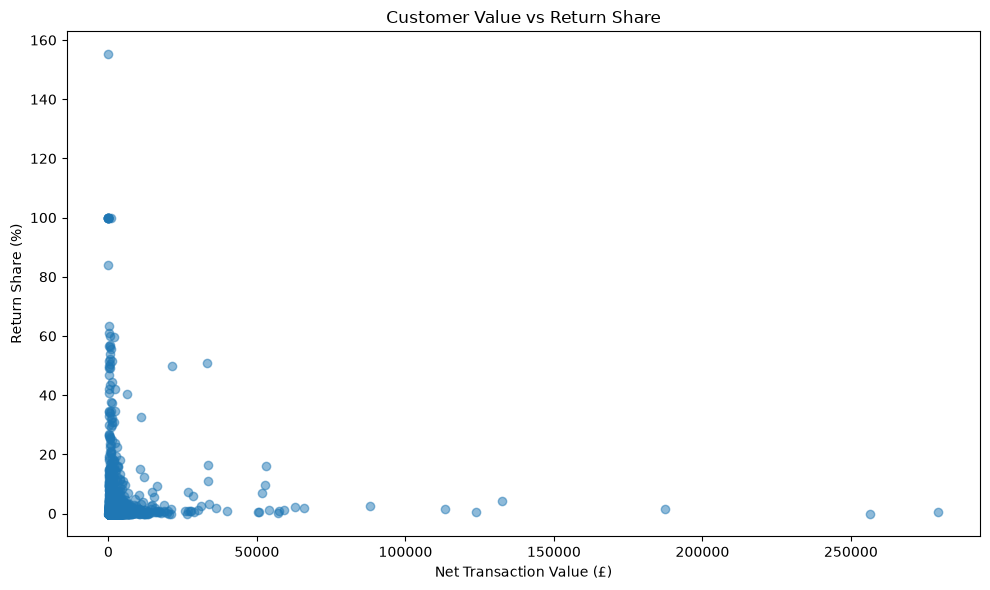

In [73]:
print("===== CUSTOMER VALUE VS RETURN SHARE =====")

plt.figure(figsize=(10, 6))

plt.scatter(
    customer_return_filtered["NetTransactionValue"],
    customer_return_filtered["ReturnShare"] * 100,
    alpha=0.5
)

plt.xlabel("Net Transaction Value (£)")
plt.ylabel("Return Share (%)")
plt.title("Customer Value vs Return Share")

plt.tight_layout()

plt.show()

In [74]:
print("===== TOP CUSTOMERS AND RETURN BEHAVIOR =====")

top_value_customers_return = (
    customer_return_filtered
    .sort_values("NetTransactionValue", ascending=False)
    .head(20)
    .copy()
)

top_value_customers_return["ReturnSharePercent"] = (
    top_value_customers_return["ReturnShare"] * 100
)

display(
    top_value_customers_return[
        [
            "NetTransactionValue",
            "TotalUnits",
            "ReturnedUnits",
            "ReturnSharePercent",
            "TransactionCount"
        ]
    ]
)

===== TOP CUSTOMERS AND RETURN BEHAVIOR =====


,NetTransactionValue,TotalUnits,ReturnedUnits,ReturnSharePercent,TransactionCount
CustomerID,,,,,
14646.0,279489.02,197491,772,0.390904,2085
18102.0,256438.49,64124,2,0.003119,433
17450.0,187322.17,69973,964,1.377674,350
14911.0,132458.73,80490,3335,4.143372,5898
12415.0,123725.45,77670,428,0.551049,778
14156.0,113214.59,57768,860,1.488713,1415
17511.0,88125.38,64549,1537,2.381137,1076
16684.0,65892.08,50255,865,1.721222,281
13694.0,62690.54,63312,1413,2.231804,584


In [75]:
print("===== CUSTOMER ANALYSIS VALIDATION =====")

known_customer_mask = df_clean["CustomerID"].notna()

customer_transaction_value = df_clean.loc[
    known_customer_mask,
    "TransactionValue"
].sum()

customer_transaction_count = known_customer_mask.sum()

customer_count = df_clean.loc[
    known_customer_mask,
    "CustomerID"
].nunique()
    
print(f"Transaction value from known customers: £{customer_transaction_value:,.2f}")
print(f"Transactions with known CustomerID: {customer_transaction_count:,}")
print(f"Unique customers: {customer_count:,}")

print("\nComparison with previous customer analysis:")
print(f"Previous transaction value: £8,272,112.93")
print(f"Previous transactions: 399,827")
print(f"Previous customers: 4,363")

===== CUSTOMER ANALYSIS VALIDATION =====
Transaction value from known customers: £8,278,519.42
Transactions with known CustomerID: 401,604
Unique customers: 4,372

Comparison with previous customer analysis:
Previous transaction value: £8,272,112.93
Previous transactions: 399,827
Previous customers: 4,363


In [76]:
print("===== CREATING FINAL CUSTOMER ANALYSIS DATASET =====")

# Customer-level analysis requires a known CustomerID.
# Start directly from the final cleaned dataset.
df_customer = df_clean[
    df_clean["CustomerID"].notna()
].copy()

print(f"Customer analysis rows: {len(df_customer):,}")
print(f"Unique customers: {df_customer['CustomerID'].nunique():,}")
print(
    f"Customer transaction value: "
    f"£{df_customer['TransactionValue'].sum():,.2f}"
)

print("\nValidation checks:")
print(
    f"Missing CustomerID: "
    f"{df_customer['CustomerID'].isna().sum():,}"
)
print(
    f"Duplicate rows: "
    f"{df_customer.duplicated().sum():,}"
)
print(
    f"Minimum CustomerID: "
    f"{df_customer['CustomerID'].min():.0f}"
)
print(
    f"Maximum CustomerID: "
    f"{df_customer['CustomerID'].max():.0f}"
)

===== CREATING FINAL CUSTOMER ANALYSIS DATASET =====
Customer analysis rows: 401,604
Unique customers: 4,372
Customer transaction value: £8,278,519.42

Validation checks:
Missing CustomerID: 0
Duplicate rows: 0
Minimum CustomerID: 12346
Maximum CustomerID: 18287


In [77]:
print("===== BUILDING FINAL CUSTOMER SUMMARY =====")

customer_summary = (
    df_customer
    .groupby("CustomerID")
    .agg(
        NetTransactionValue=("TransactionValue", "sum"),
        TotalUnits=("Quantity", "sum"),
        TransactionCount=("TransactionValue", "count"),
        InvoiceCount=("InvoiceNo", "nunique")
    )
    .sort_values("NetTransactionValue", ascending=False)
)

print(f"Unique customers in summary: {len(customer_summary):,}")

print("\nTop 20 customers by net transaction value:")
display(customer_summary.head(20))

print("\n===== CUSTOMER SUMMARY VALIDATION =====")

print(
    f"Summary transaction value: "
    f"£{customer_summary['NetTransactionValue'].sum():,.2f}"
)

print(
    f"Original customer transaction value: "
    f"£{df_customer['TransactionValue'].sum():,.2f}"
)

print(
    f"Value difference: "
    f"£{customer_summary['NetTransactionValue'].sum() - df_customer['TransactionValue'].sum():,.2f}"
)

===== BUILDING FINAL CUSTOMER SUMMARY =====
Unique customers in summary: 4,372

Top 20 customers by net transaction value:


,NetTransactionValue,TotalUnits,TransactionCount,InvoiceCount
CustomerID,,,,
14646.0,279489.02,196719,2085,77
18102.0,256438.49,64122,433,62
17450.0,187322.17,69009,350,55
14911.0,132458.73,77155,5898,248
12415.0,123725.45,77242,778,26
14156.0,113214.59,56908,1415,66
17511.0,88125.38,63012,1076,46
16684.0,65892.08,49390,281,31
13694.0,62690.54,61899,584,60



===== CUSTOMER SUMMARY VALIDATION =====
Summary transaction value: £8,278,519.42
Original customer transaction value: £8,278,519.42
Value difference: £0.00


## 10. Customer Value Concentration

Customer transaction value is analyzed to determine how concentrated the business is among its highest-value customers.

The analysis calculates the share of identifiable customer transaction value generated by:

- Top 1% of customers
- Top 5% of customers
- Top 10% of customers
- Top 20% of customers

This provides a useful view of customer concentration and potential dependence on high-value customers.

A high concentration means that a relatively small group of customers contributes a substantial proportion of identifiable transaction value.

In [78]:
print("===== FINAL CUSTOMER REVENUE CONCENTRATION =====")

# Customers are already ranked by net transaction value.
customer_ranked = customer_summary.copy()

total_customer_value = customer_ranked["NetTransactionValue"].sum()
total_customers = len(customer_ranked)

# Calculate cumulative revenue contribution
customer_ranked["CumulativeValue"] = (
    customer_ranked["NetTransactionValue"].cumsum()
)

customer_ranked["CumulativeRevenueShare"] = (
    customer_ranked["CumulativeValue"]
    / total_customer_value
)

# Calculate revenue concentration for top customer groups
concentration_results = []

for percentage, label in [
    (0.01, "Top 1%"),
    (0.05, "Top 5%"),
    (0.10, "Top 10%"),
    (0.20, "Top 20%")
]:
    customer_count = int(total_customers * percentage)

    group_value = customer_ranked.iloc[:customer_count][
        "NetTransactionValue"
    ].sum()

    revenue_share = group_value / total_customer_value

    concentration_results.append({
        "CustomerGroup": label,
        "Customers": customer_count,
        "NetTransactionValue": group_value,
        "RevenueShare": revenue_share
    })

customer_concentration = pd.DataFrame(concentration_results)

print(f"Total identifiable customers: {total_customers:,}")
print(
    f"Total identifiable-customer transaction value: "
    f"£{total_customer_value:,.2f}"
)

print("\nTop customer concentration:")
display(customer_concentration)

===== FINAL CUSTOMER REVENUE CONCENTRATION =====
Total identifiable customers: 4,372
Total identifiable-customer transaction value: £8,278,519.42

Top customer concentration:


,CustomerGroup,Customers,NetTransactionValue,RevenueShare
0,Top 1%,43,2466457.030,0.297935
1,Top 5%,218,4024436.250,0.486130
2,Top 10%,437,4975105.690,0.600966
3,Top 20%,874,6117715.101,0.738987


In [79]:
print("===== FINAL CUSTOMER PURCHASE FREQUENCY =====")

customer_frequency = customer_summary.copy()

customer_frequency["PurchaseFrequencyGroup"] = pd.cut(
    customer_frequency["InvoiceCount"],
    bins=[0, 1, 4, 9, np.inf],
    labels=[
        "One-time (1 invoice)",
        "Occasional (2-4 invoices)",
        "Repeat (5-9 invoices)",
        "Frequent (10+ invoices)"
    ]
)

frequency_summary = (
    customer_frequency
    .groupby(
        "PurchaseFrequencyGroup",
        observed=False
    )
    .agg(
        CustomerCount=("NetTransactionValue", "count"),
        NetTransactionValue=("NetTransactionValue", "sum"),
        AverageCustomerValue=("NetTransactionValue", "mean")
    )
)

frequency_summary["CustomerShare"] = (
    frequency_summary["CustomerCount"]
    / frequency_summary["CustomerCount"].sum()
)

frequency_summary["RevenueShare"] = (
    frequency_summary["NetTransactionValue"]
    / frequency_summary["NetTransactionValue"].sum()
)

print(
    f"Total customers classified: "
    f"{frequency_summary['CustomerCount'].sum():,}"
)

print(
    f"Total transaction value: "
    f"£{frequency_summary['NetTransactionValue'].sum():,.2f}"
)

display(frequency_summary)

===== FINAL CUSTOMER PURCHASE FREQUENCY =====
Total customers classified: 4,372
Total transaction value: £8,278,519.42


,CustomerCount,NetTransactionValue,AverageCustomerValue,CustomerShare,RevenueShare
PurchaseFrequencyGroup,,,,,
One-time (1 invoice),1313,431608.861,328.719620,0.300320,0.052136
Occasional (2-4 invoices),1684,1335939.232,793.313083,0.385178,0.161374
Repeat (5-9 invoices),838,1644793.831,1962.761135,0.191674,0.198682
Frequent (10+ invoices),537,4866177.500,9061.783054,0.122827,0.587808


In [80]:
print("===== FINAL CUSTOMER VALUE BY COUNTRY =====")

customer_country = (
    df_customer
    .groupby("Country")
    .agg(
        NetTransactionValue=("TransactionValue", "sum"),
        CustomerCount=("CustomerID", "nunique"),
        TransactionCount=("TransactionValue", "count")
    )
    .sort_values(
        "NetTransactionValue",
        ascending=False
    )
)

customer_country["AverageCustomerValue"] = (
    customer_country["NetTransactionValue"]
    / customer_country["CustomerCount"]
)

print("Top 20 countries by identifiable-customer transaction value:")

display(
    customer_country.head(20)
)

===== FINAL CUSTOMER VALUE BY COUNTRY =====
Top 20 countries by identifiable-customer transaction value:


,NetTransactionValue,CustomerCount,TransactionCount,AverageCustomerValue
Country,,,,
United Kingdom,6747156.154,3950,356728,1708.140798
Netherlands,284661.540,9,2371,31629.060000
EIRE,250001.780,3,7475,83333.926667
Germany,221509.470,95,9480,2331.678632
France,196626.050,87,8475,2260.069540
Australia,137009.770,9,1258,15223.307778
Switzerland,55739.400,21,1877,2654.257143
Spain,54756.030,31,2528,1766.323548
Belgium,40910.960,25,2069,1636.438400


In [81]:
print("===== FINAL AVERAGE CUSTOMER VALUE BY COUNTRY =====")

minimum_customers = 5

country_avg_value = (
    customer_country[
        customer_country["CustomerCount"] >= minimum_customers
    ]
    .sort_values(
        "AverageCustomerValue",
        ascending=False
    )
)

print(
    f"Countries included: "
    f"{len(country_avg_value)}"
)

print(
    f"Minimum identifiable customers per country: "
    f"{minimum_customers}"
)

display(country_avg_value)

===== FINAL AVERAGE CUSTOMER VALUE BY COUNTRY =====
Countries included: 19
Minimum identifiable customers per country: 5


,NetTransactionValue,CustomerCount,TransactionCount,AverageCustomerValue
Country,,,,
Netherlands,284661.540,9,2371,31629.060000
Australia,137009.770,9,1258,15223.307778
Sweden,36585.410,8,461,4573.176250
Japan,35340.620,8,358,4417.577500
Norway,35163.460,10,1086,3516.346000
Switzerland,55739.400,21,1877,2654.257143
Germany,221509.470,95,9480,2331.678632
France,196626.050,87,8475,2260.069540
Channel Islands,20076.390,9,757,2230.710000


In [82]:
print("===== FINAL CUSTOMER SEGMENTATION =====")

customer_segmentation = (
    customer_frequency
    .groupby(
        "PurchaseFrequencyGroup",
        observed=False
    )
    .agg(
        CustomerCount=("NetTransactionValue", "count"),
        TotalValue=("NetTransactionValue", "sum"),
        AverageCustomerValue=("NetTransactionValue", "mean"),
        MedianCustomerValue=("NetTransactionValue", "median"),
        MinCustomerValue=("NetTransactionValue", "min"),
        MaxCustomerValue=("NetTransactionValue", "max")
    )
)

customer_segmentation["CustomerShare"] = (
    customer_segmentation["CustomerCount"]
    / customer_segmentation["CustomerCount"].sum()
)

customer_segmentation["RevenueShare"] = (
    customer_segmentation["TotalValue"]
    / customer_segmentation["TotalValue"].sum()
)

display(customer_segmentation)

===== FINAL CUSTOMER SEGMENTATION =====


,CustomerCount,TotalValue,AverageCustomerValue,MedianCustomerValue,MinCustomerValue,MaxCustomerValue,CustomerShare,RevenueShare
PurchaseFrequencyGroup,,,,,,,,
One-time (1 invoice),1313,431608.861,328.719620,232.030,-4287.63,6207.67,0.300320,0.052136
Occasional (2-4 invoices),1684,1335939.232,793.313083,599.155,-840.76,21535.90,0.385178,0.161374
Repeat (5-9 invoices),838,1644793.831,1962.761135,1597.965,-1165.30,13375.87,0.191674,0.198682
Frequent (10+ invoices),537,4866177.500,9061.783054,4105.070,515.73,279489.02,0.122827,0.587808


In [83]:
print("===== CUSTOMER VALUE BY PURCHASE FREQUENCY =====")

frequency_chart = (
    customer_segmentation
    .reset_index()
    [["PurchaseFrequencyGroup", "AverageCustomerValue"]]
)

display(frequency_chart)

===== CUSTOMER VALUE BY PURCHASE FREQUENCY =====


,PurchaseFrequencyGroup,AverageCustomerValue
0,One-time (1 invoice),328.719620
1,Occasional (2-4 invoices),793.313083
2,Repeat (5-9 invoices),1962.761135
3,Frequent (10+ invoices),9061.783054


## 11. Customer Return Behavior

Customer-level return behavior is analyzed using sold and returned units.

A customer's return share is calculated as the proportion of returned units relative to the total units sold plus returned:

**Return Share = Returned Units / (Sold Units + Returned Units)**

This approach avoids return rates above 100% that can occur when returned units are divided directly by sold units.

Customers with no recorded returns are assigned a return share of zero.

For identifying unusually high-return customers, the analysis focuses on customers with at least 100 units sold. This provides a meaningful sales base and avoids highlighting customers whose return percentage is driven by very small transaction volumes.

In [84]:
print("===== FINAL CUSTOMER RETURN ANALYSIS =====")

customer_return_analysis = (
    df_customer
    .groupby("CustomerID")
    .agg(
        SoldUnits=("Quantity", lambda x: x[x > 0].sum()),
        ReturnedUnits=("Quantity", lambda x: -x[x < 0].sum()),
        NetTransactionValue=("TransactionValue", "sum"),
        TransactionCount=("TransactionValue", "count")
    )
)

customer_return_analysis["ReturnShare"] = (
    customer_return_analysis["ReturnedUnits"]
    / (
        customer_return_analysis["SoldUnits"]
        + customer_return_analysis["ReturnedUnits"]
    )
)

customer_return_analysis["ReturnShare"] = (
    customer_return_analysis["ReturnShare"].fillna(0)
)

print(
    f"Total customers: "
    f"{len(customer_return_analysis):,}"
)

print(
    f"Customers with at least one return: "
    f"{(customer_return_analysis['ReturnedUnits'] > 0).sum():,}"
)

print(
    f"Total units sold: "
    f"{customer_return_analysis['SoldUnits'].sum():,}"
)

print(
    f"Total units returned: "
    f"{customer_return_analysis['ReturnedUnits'].sum():,}"
)

display(
    customer_return_analysis
    .sort_values("ReturnShare", ascending=False)
    .head(20)
)

===== FINAL CUSTOMER RETURN ANALYSIS =====
Total customers: 4,372
Customers with at least one return: 1,589
Total units sold: 5,165,886
Total units returned: 273,035


,SoldUnits,ReturnedUnits,NetTransactionValue,TransactionCount,ReturnShare
CustomerID,,,,,
18256.0,0,70,-50.10,4,1.0
13154.0,0,1,-611.86,1,1.0
13693.0,0,6,-32.00,4,1.0
15369.0,0,1,-1592.49,1,1.0
18141.0,0,12,-35.40,1,1.0
16579.0,0,12,-30.60,1,1.0
13958.0,0,23,-102.45,5,1.0
16428.0,0,1,-2.95,1,1.0
12943.0,0,1,-3.75,1,1.0


In [85]:
print("===== FINAL CUSTOMER RETURN BEHAVIOR =====")

customer_return_filtered = (
    customer_return_analysis[
        customer_return_analysis["SoldUnits"] >= 100
    ]
    .copy()
    .sort_values(
        "ReturnShare",
        ascending=False
    )
)

print(
    f"Customers with at least 100 units sold: "
    f"{len(customer_return_filtered):,}"
)

print(
    f"Customers with at least 100 units sold and at least one return: "
    f"{(customer_return_filtered['ReturnedUnits'] > 0).sum():,}"
)

display(
    customer_return_filtered.head(20)
)

===== FINAL CUSTOMER RETURN BEHAVIOR =====
Customers with at least 100 units sold: 3,710
Customers with at least 100 units sold and at least one return: 1,478


,SoldUnits,ReturnedUnits,NetTransactionValue,TransactionCount,ReturnShare
CustomerID,,,,,
16546.0,549,852,-9.593000e+01,31,0.608137
12908.0,1200,1200,2.460000e+02,4,0.500000
12454.0,1006,1006,5.684342e-14,30,0.500000
18133.0,1350,1350,7.155000e+02,2,0.500000
13762.0,272,272,3.552714e-15,14,0.500000
12346.0,74215,74215,0.000000e+00,2,0.500000
12607.0,1228,1228,3.552714e-15,202,0.500000
14557.0,510,510,0.000000e+00,32,0.500000
12558.0,196,196,1.065814e-14,22,0.500000


## 12. High-Value Customers with High Return Activity

To identify customers who may require further business attention, customer value and return behavior are evaluated together.

A customer is classified as **high value** when their transaction value is within the top 10% of identifiable customers.

The analysis then identifies customers who also have an unusually high return share.

This helps distinguish:

- High-value customers with relatively normal return behavior
- High-value customers with elevated return activity
- Customers who may warrant further investigation or targeted retention analysis

The results should be treated as a prioritization signal rather than evidence of customer problems, since return behavior can have legitimate business explanations.

In [86]:
print("===== HIGH-VALUE / HIGH-RETURN CUSTOMERS =====")

# Top 10% customer value threshold
customer_value_threshold = customer_summary[
    "NetTransactionValue"
].quantile(0.90)

high_value_high_return = customer_return_filtered[
    (customer_return_filtered["NetTransactionValue"] >= customer_value_threshold)
    & (customer_return_filtered["ReturnShare"] >= 0.20)
].copy()

high_value_high_return = high_value_high_return.sort_values(
    ["NetTransactionValue", "ReturnShare"],
    ascending=[False, False]
)

print(
    f"Top 10% customer value threshold: "
    f"£{customer_value_threshold:,.2f}"
)

print(
    f"High-value/high-return customers: "
    f"{len(high_value_high_return):,}"
)

display(high_value_high_return)

===== HIGH-VALUE / HIGH-RETURN CUSTOMERS =====
Top 10% customer value threshold: £3,496.20
High-value/high-return customers: 4


,SoldUnits,ReturnedUnits,NetTransactionValue,TransactionCount,ReturnShare
CustomerID,,,,,
15838.0,18368,9361,33350.76,169,0.337589
15749.0,18028,9014,21535.90,15,0.333333
14607.0,11526,3768,10981.10,109,0.246371
15482.0,5004,2022,6393.52,126,0.287788


===== CUSTOMER PURCHASE FREQUENCY CHART =====


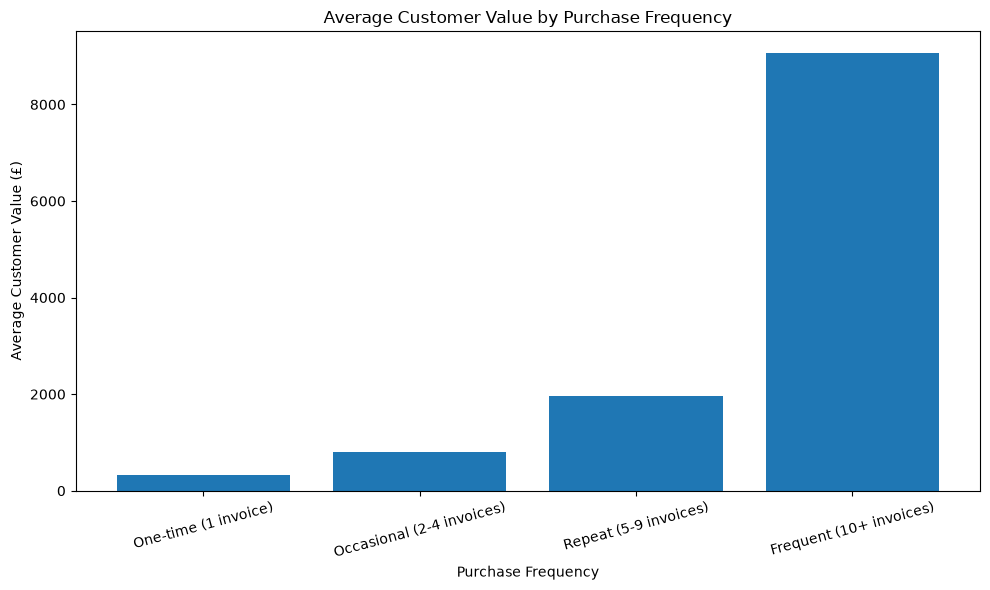

In [87]:
print("===== CUSTOMER PURCHASE FREQUENCY CHART =====")

plt.figure(figsize=(10, 6))

plt.bar(
    frequency_chart["PurchaseFrequencyGroup"],
    frequency_chart["AverageCustomerValue"]
)

plt.title("Average Customer Value by Purchase Frequency")
plt.xlabel("Purchase Frequency")
plt.ylabel("Average Customer Value (£)")
plt.xticks(rotation=15)
plt.tight_layout()

plt.show()

===== CUSTOMER REVENUE CONTRIBUTION BY FREQUENCY =====


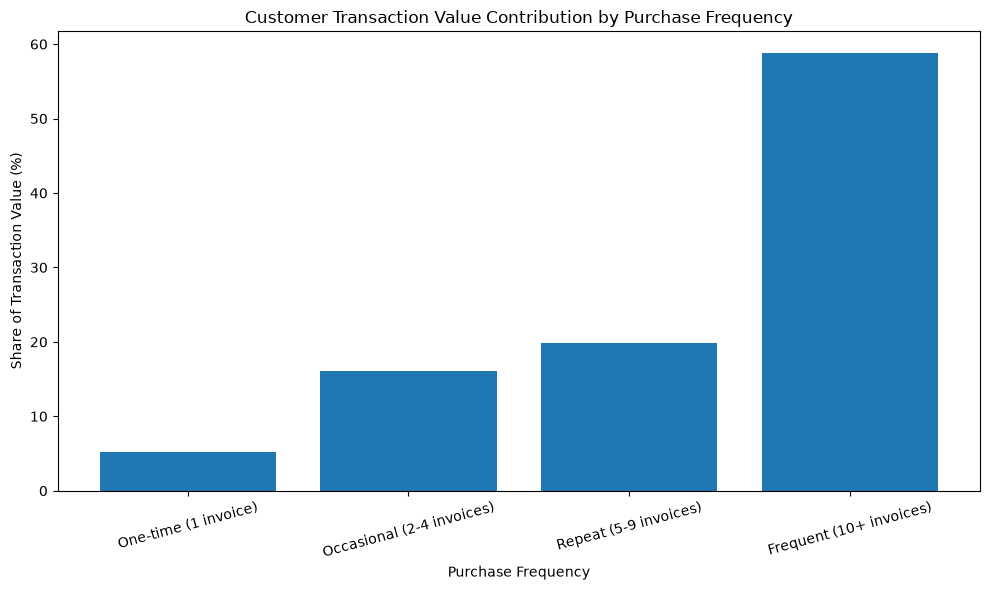

In [88]:
print("===== CUSTOMER REVENUE CONTRIBUTION BY FREQUENCY =====")

revenue_chart = (
    frequency_summary
    .reset_index()
    [["PurchaseFrequencyGroup", "RevenueShare"]]
)

plt.figure(figsize=(10, 6))

plt.bar(
    revenue_chart["PurchaseFrequencyGroup"],
    revenue_chart["RevenueShare"] * 100
)

plt.title("Customer Transaction Value Contribution by Purchase Frequency")
plt.xlabel("Purchase Frequency")
plt.ylabel("Share of Transaction Value (%)")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

===== CUSTOMER RETURN SHARE DISTRIBUTION =====


ReturnShare
No returns    2232
0-5%          1273
5-10%           85
10-20%          62
20-50%          57
50%+             1
Name: count, dtype: int64

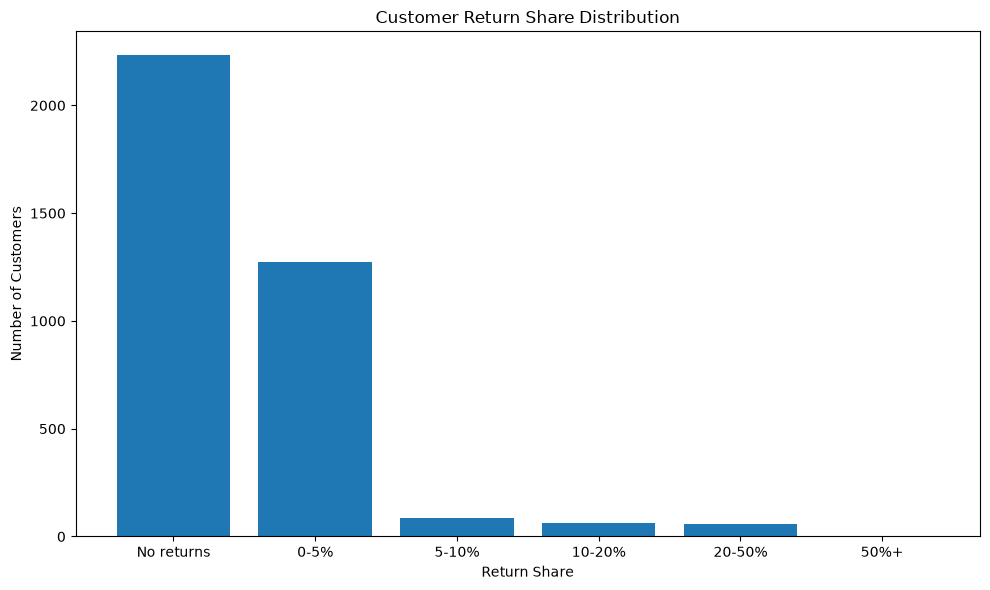

In [89]:
print("===== CUSTOMER RETURN SHARE DISTRIBUTION =====")

return_distribution = pd.cut(
    customer_return_filtered["ReturnShare"],
    bins=[-0.001, 0, 0.05, 0.10, 0.20, 0.50, 1.00],
    labels=[
        "No returns",
        "0-5%",
        "5-10%",
        "10-20%",
        "20-50%",
        "50%+"
    ]
).value_counts().sort_index()

display(return_distribution)

plt.figure(figsize=(10, 6))

plt.bar(
    return_distribution.index.astype(str),
    return_distribution.values
)

plt.title("Customer Return Share Distribution")
plt.xlabel("Return Share")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

===== CUSTOMER VALUE VS RETURN SHARE =====


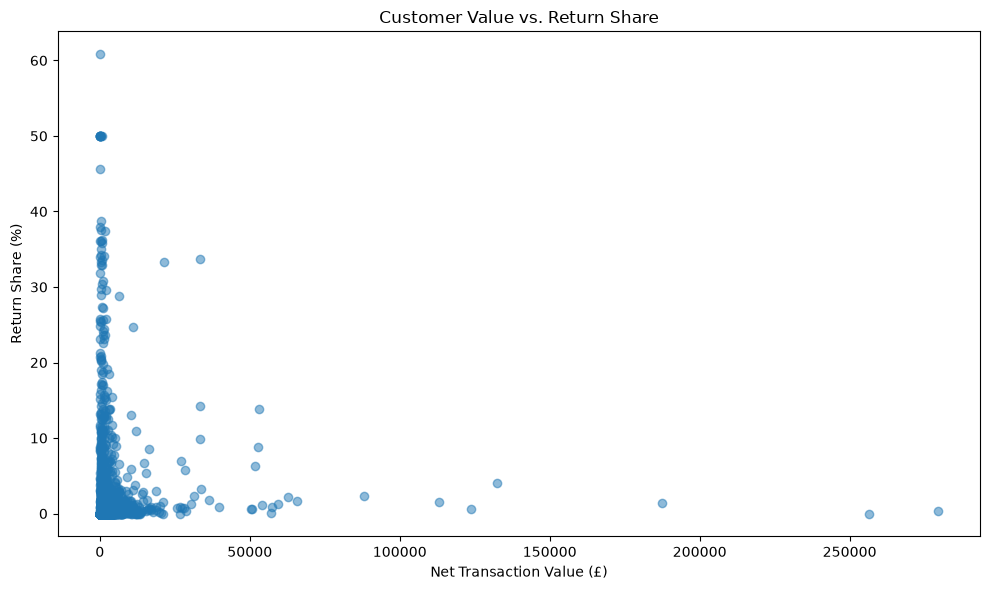

In [90]:
print("===== CUSTOMER VALUE VS RETURN SHARE =====")

plt.figure(figsize=(10, 6))

plt.scatter(
    customer_return_filtered["NetTransactionValue"],
    customer_return_filtered["ReturnShare"] * 100,
    alpha=0.5
)

plt.title("Customer Value vs. Return Share")
plt.xlabel("Net Transaction Value (£)")
plt.ylabel("Return Share (%)")

plt.tight_layout()
plt.show()

In [91]:
print("===== CUSTOMER VALUE / RETURN SHARE CORRELATION =====")

correlation = customer_return_filtered[
    ["NetTransactionValue", "ReturnShare"]
].corr().loc[
    "NetTransactionValue",
    "ReturnShare"
]

print(
    f"Pearson correlation: {correlation:.4f}"
)

if correlation > 0.3:
    interpretation = "Positive relationship"
elif correlation < -0.3:
    interpretation = "Negative relationship"
else:
    interpretation = "Weak or negligible linear relationship"

print(
    f"Interpretation: {interpretation}"
)

===== CUSTOMER VALUE / RETURN SHARE CORRELATION =====
Pearson correlation: 0.0209
Interpretation: Weak or negligible linear relationship


## 13. Key Business Findings

The analysis produced several important business insights:

### Data quality
- Exact duplicates represented **0.97%** of the original dataset and were removed.
- Missing CustomerID values affected approximately **24.93%** of records, so customer-level analysis was restricted to identifiable customers.
- Negative quantities were retained as legitimate return/cancellation activity rather than being treated as errors.

### Sales performance
- The UK generated the majority of transaction value, indicating strong geographic concentration.
- **November 2011** was the highest complete month by transaction value.
- December 2011 is incomplete and should not be directly compared with complete months.

### Product performance
- A relatively small number of products generated a large share of product transaction value.
- Some products showed unusually high return shares, but correction and zero-value transactions require careful interpretation.

### Customer behavior
- Frequent customers represented only **12.28%** of identifiable customers but contributed approximately **58.78%** of identifiable-customer transaction value.
- The top **10%** of identifiable customers contributed approximately **60.10%** of identifiable-customer transaction value.
- Customer value and return share showed a very weak linear relationship, with a Pearson correlation of approximately **0.02**.

### Business implications

The retailer appears to depend substantially on a relatively small group of high-value and frequent customers. This suggests that customer retention and high-value customer management could be important areas for further analysis.

Return behavior should be monitored at both product and customer levels, while accounting for legitimate cancellations and correction transactions.

In [92]:
print("===== PROJECT 02 FINAL KPI SUMMARY =====")

total_rows_original = len(df)
total_rows_clean = len(df_clean)

gross_sales = df_clean.loc[
    df_clean["Quantity"] > 0,
    "TransactionValue"
].sum()

return_value = df_clean.loc[
    df_clean["Quantity"] < 0,
    "TransactionValue"
].sum()

net_value = df_clean["TransactionValue"].sum()

return_rate_units = (
    customer_return_analysis["ReturnedUnits"].sum()
    / (
        customer_return_analysis["SoldUnits"].sum()
        + customer_return_analysis["ReturnedUnits"].sum()
    )
)

customers_with_returns = (
    customer_return_analysis["ReturnedUnits"] > 0
).sum()

frequent_customers = frequency_summary.loc[
    "Frequent (10+ invoices)",
    "CustomerCount"
]

frequent_revenue_share = frequency_summary.loc[
    "Frequent (10+ invoices)",
    "RevenueShare"
]

print(f"Original rows: {total_rows_original:,}")
print(f"Cleaned rows: {total_rows_clean:,}")
print(f"Gross sales value: £{gross_sales:,.2f}")
print(f"Return/cancellation value: £{return_value:,.2f}")
print(f"Net transaction value: £{net_value:,.2f}")
print(f"Identifiable customers: {len(customer_summary):,}")
print(f"Customers with returns: {customers_with_returns:,}")
print(f"Customer-level return share: {return_rate_units:.2%}")
print(f"Frequent customers: {frequent_customers:,}")
print(f"Frequent-customer value share: {frequent_revenue_share:.2%}")
print(f"Customer value/return correlation: {correlation:.4f}")
print(f"High-value/high-return customers: {len(high_value_high_return):,}")

===== PROJECT 02 FINAL KPI SUMMARY =====
Original rows: 541,909
Cleaned rows: 536,639
Gross sales value: £10,642,110.80
Return/cancellation value: £-893,979.73
Net transaction value: £9,748,131.07
Identifiable customers: 4,372
Customers with returns: 1,589
Customer-level return share: 5.02%
Frequent customers: 537
Frequent-customer value share: 58.78%
Customer value/return correlation: 0.0209
High-value/high-return customers: 4


# Project 02 — Online Retail Data Cleaning & Exploratory Data Analysis

## Business Objective

Analyze and clean a large online retail transaction dataset to understand:

- Data quality and missing-value patterns
- Duplicate and anomalous transactions
- Sales and return behavior over time
- Geographic sales concentration
- Product performance
- Customer purchase frequency and value
- Customer return behavior
- High-value customers with unusually high return activity

## Dataset

**Source:** UCI Machine Learning Repository — Online Retail Dataset

The dataset contains transaction-level records from a UK-based online retailer covering December 2010 through December 2011.

### Key Questions

1. What data-quality issues exist in the raw dataset?
2. How should duplicates, cancellations, returns, and unusual prices be handled?
3. Which countries and products contribute most to transaction value?
4. How does customer purchase frequency relate to customer value?
5. How concentrated is customer transaction value?
6. How common is return behavior?
7. Is customer value associated with return behavior?